# Predicción del Precio de Bolsa — Mercado Eléctrico Colombiano
## Entrega 1: Problema · Datos · EDA · Baseline

**Curso:** Aprendizaje de Máquina Aplicado  
**Profesor:** Marco Terán — Universidad EAFIT  
**Fecha:** Abril 2026

---

## Tabla de contenidos

1. [Definición del problema](#problema)
   - 1b. Tipo de tarea: regresión supervisada
2. [Setup y dependencias](#setup)
3. [Carga de datos](#carga)
4. [Auditoría de calidad](#calidad)
   - 4b. Herramientas visuales: Boxplot, Q-Q Plot, Violin
5. [EDA — Análisis del target](#target)
6. [EDA — Variables: relaciones, señal predictiva y selección](#eda)
   - 6a. Relaciones entre variables
   - 6b. Relaciones con el target
   - 6c. Evaluación de reducción de features
   - 6e. Pearson vs Spearman y forma funcional
7. [EDA — Fenómeno El Niño 2023-2024](#nino)
8. [Análisis de redundancia de columnas originales](#redundancia)
   - 8b. Justificación del escalado (StandardScaler)
9. [Feature engineering — 5 features justificadas](#engineering)
10. [Partición temporal](#split)
11. [Baseline reproducible](#baseline)
    - 11b. Feature importance — coeficientes Ridge
12. [Conclusiones y próximos pasos](#conclusiones)

---
## 1. Definición del problema <a name="problema"></a>

### ¿Qué problema intentamos resolver?

Predecir el **precio de bolsa de la electricidad en Colombia** a partir de variables diarias del estado del sistema eléctrico. El precio de bolsa es el precio marginal del mercado mayorista, determinado principalmente por la disponibilidad hídrica y la mezcla de generación.

### Variable objetivo

`precio_bolsa_kwh` — precio de bolsa ponderado diario en $/kWh  
**Transformación:** `log(precio_bolsa_kwh)` para el entrenamiento, dado el skew=2.158

### Métrica principal

**RMSE en escala original ($/kWh)** — penaliza errores grandes, coherente con el impacto económico de una mala predicción de precio.

### 1b. Tipo de tarea: aprendizaje supervisado de regresión

| Característica | Detalle |
|---|---|
| **Tipo de aprendizaje** | Supervisado — tenemos pares (X, y) donde y es el precio histórico |
| **Tipo de tarea** | **Regresión** — el target `precio_bolsa_kwh` es una variable continua ($/kWh) |
| **¿Por qué no clasificación?** | No predecimos categorías (caro/barato) sino el valor numérico exacto |
| **Métrica apropiada** | RMSE en $/kWh — penaliza errores grandes, coherente con impacto económico |
| **Variable objetivo** | `precio_bolsa_kwh` → entrenada como `log(precio_bolsa_kwh)` por skew=2.158 |

> **Regla del curso:** la métrica debe ser apropiada para el tipo de tarea.
> Para regresión con impacto económico asimétrico, el RMSE es la elección correcta.

---
## 2. Setup y dependencias <a name="setup"></a>

In [1]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Crear carpeta de figuras si no existe
os.makedirs('figures', exist_ok=True)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

try:
    from IPython.display import display
except ImportError:
    display = print

print('✅ Entorno configurado — SEED =', SEED)
print('✅ Carpeta figures/ lista')

✅ Entorno configurado — SEED = 42
✅ Carpeta figures/ lista


---
## 3. Carga de datos <a name="carga"></a>

Los datos provienen de **7 archivos CSV independientes** del operador del sistema eléctrico colombiano (XM), ya integrados en un único archivo `dataset_energia_colombia.csv` (1,155 filas × 16 columnas).

> `TARGET = 'precio_bolsa_kwh'` se define aquí y es usado en todas las secciones siguientes.

In [2]:
# ── Constante global del target ──────────────────────────────────────────
TARGET = 'precio_bolsa_kwh'

# ── Carga del dataset integrado ───────────────────────────────────────────
dataset = pd.read_csv('dataset_energia_colombia.csv', parse_dates=['date'])

print(f'Shape      : {dataset.shape}')
print(f'Período    : {dataset["date"].min().date()} → {dataset["date"].max().date()}')
print(f'TARGET     : {TARGET}')
print(f'Columnas   : {list(dataset.columns)}')
display(dataset.head(3))

Shape      : (1155, 16)
Período    : 2023-02-01 → 2026-03-31
TARGET     : precio_bolsa_kwh
Columnas   : ['date', 'aportes_energia_gwh', 'precio_bolsa_kwh', 'precio_escasez_kwh', 'reservas_pct', 'gen_total_kwh', 'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro', 'demanda_kwh', 'demanda_max', 'demanda_min', 'demanda_promedio', 'demanda_pico']


,date,aportes_energia_gwh,precio_bolsa_kwh,precio_escasez_kwh,reservas_pct,gen_total_kwh,gen_hidro,gen_termica,gen_solar,gen_eolica,ratio_hidro,demanda_kwh,demanda_max,demanda_min,demanda_promedio,demanda_pico
0,2023-02-01,"108,792,500.000",771.110,"1,122.500",0.640,227762191,168923769,55595956,2661892,580574,74.170,8971529,10174501,7207945,8971529,9888791
1,2023-02-02,"115,285,000.000",732.440,"1,122.500",0.640,226701934,162273638,61069500,2591876,766919,71.580,8943824,10272107,7145866,8943824,9944709
2,2023-02-03,"103,379,000.000",796.620,"1,122.500",0.630,228792944,158638445,66899569,2515899,739031,69.340,9049609,10287723,7242398,9049609,9995476


---
## 4. Auditoría de calidad <a name="calidad"></a>

In [3]:
print('=== TIPOS DE DATO ===')
print(dataset.dtypes)

print('\n=== VALORES FALTANTES ===')
miss = dataset.isna().sum()
if miss.sum() == 0:
    print('✅ Sin valores faltantes en ninguna columna')
else:
    print(miss[miss > 0])

print('\n=== DUPLICADOS ===')
dups = dataset.duplicated().sum()
print(f'✅ Filas duplicadas exactas: {dups}' if dups == 0 else f'⚠️ {dups} filas duplicadas')

=== TIPOS DE DATO ===
date                   datetime64[ns]
aportes_energia_gwh           float64
precio_bolsa_kwh              float64
precio_escasez_kwh            float64
reservas_pct                  float64
gen_total_kwh                   int64
gen_hidro                       int64
gen_termica                     int64
gen_solar                       int64
gen_eolica                      int64
ratio_hidro                   float64
demanda_kwh                     int64
demanda_max                     int64
demanda_min                     int64
demanda_promedio                int64
demanda_pico                    int64
dtype: object

=== VALORES FALTANTES ===
✅ Sin valores faltantes en ninguna columna

=== DUPLICADOS ===
✅ Filas duplicadas exactas: 0


In [4]:
# Perfil numérico completo
cols_num = [c for c in dataset.columns if c != 'date']
rows = []
for col in cols_num:
    s = dataset[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outlier_pct = round(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() * 100, 2)
    rows.append({
        'columna': col, 'media': round(s.mean(), 2), 'mediana': round(s.median(), 2),
        'std': round(s.std(), 2), 'min': round(s.min(), 2), 'max': round(s.max(), 2),
        'skew': round(s.skew(), 3), 'outlier_%': outlier_pct,
    })

profile = pd.DataFrame(rows)
print('=== PERFIL NUMÉRICO ===')
display(profile)

=== PERFIL NUMÉRICO ===


,columna,media,mediana,std,min,max,skew,outlier_%
0,aportes_energia_gwh,"202,297,063.080","186,969,108.910","95,779,591.500","55,824,700.000","643,404,200.000",1.082,3.120
1,precio_bolsa_kwh,474.040,355.640,374.910,101.900,"3,682.630",2.158,3.030
2,precio_escasez_kwh,947.650,928.350,103.000,790.170,"1,191.650",0.544,0.000
3,reservas_pct,0.630,0.640,0.120,0.260,0.840,-0.628,0.870
4,gen_total_kwh,"227,590,806.930","230,230,390.000","14,855,906.880","175,949,094.000","256,023,400.000",-0.747,1.210
5,gen_hidro,"167,818,155.080","171,284,263.000","26,380,248.660","78,218,277.000","214,493,360.000",-0.680,0.430
6,gen_termica,"50,419,756.920","42,300,748.000","25,829,853.600","18,181,016.000","121,926,170.000",0.812,0.000
7,gen_solar,"8,885,085.090","9,253,176.000","4,370,924.110","1,143,330.000","21,650,480.000",0.155,0.000
8,gen_eolica,"467,809.840","497,090.000","222,787.280",0.000,"916,573.000",-0.362,0.000
9,ratio_hidro,73.770,77.250,10.790,39.060,89.720,-0.884,0.690


---
## 5. EDA — Análisis del target <a name="target"></a>

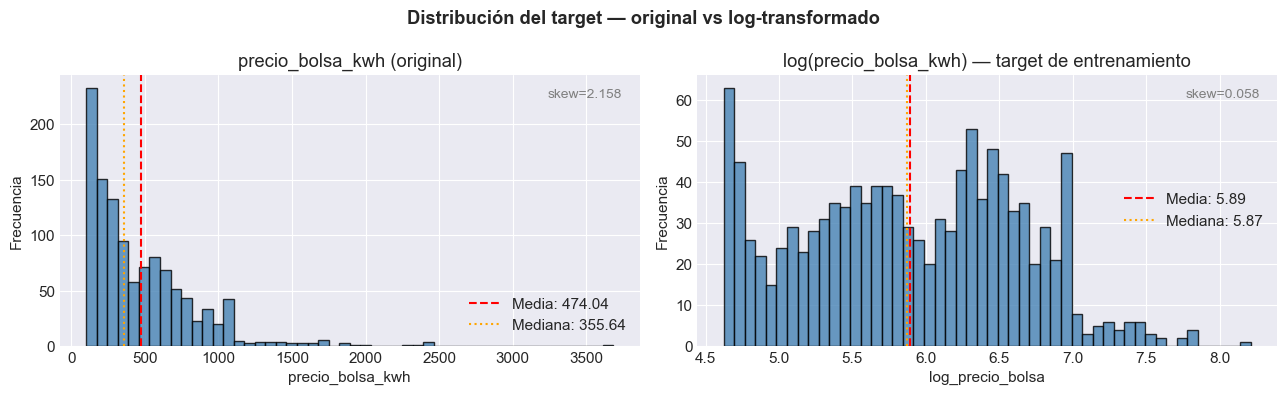


Transformación log: skew 2.158 → 0.058
Dif. media-mediana: 33.3% → 0.3%


In [5]:
dataset['log_precio_bolsa'] = np.log(dataset[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribución del target — original vs log-transformado', fontweight='bold')

for ax, col, titulo in zip(axes,
    [TARGET, 'log_precio_bolsa'],
    ['precio_bolsa_kwh (original)', 'log(precio_bolsa_kwh) — target de entrenamiento']):
    s = dataset[col]
    ax.hist(s, bins=50, edgecolor='black', alpha=0.8, color='steelblue')
    ax.axvline(s.mean(),   linestyle='--', linewidth=1.5, color='red',    label=f'Media: {s.mean():.2f}')
    ax.axvline(s.median(), linestyle=':',  linewidth=1.5, color='orange', label=f'Mediana: {s.median():.2f}')
    ax.set_title(titulo); ax.set_xlabel(col); ax.set_ylabel('Frecuencia'); ax.legend()
    ax.text(0.97, 0.95, f'skew={s.skew():.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('figures/distribucion_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTransformación log: skew {dataset[TARGET].skew():.3f} → {dataset["log_precio_bolsa"].skew():.3f}')
print(f'Dif. media-mediana: {abs(dataset[TARGET].mean()-dataset[TARGET].median())/dataset[TARGET].median()*100:.1f}%'
      f' → {abs(dataset["log_precio_bolsa"].mean()-dataset["log_precio_bolsa"].median())/dataset["log_precio_bolsa"].median()*100:.1f}%')

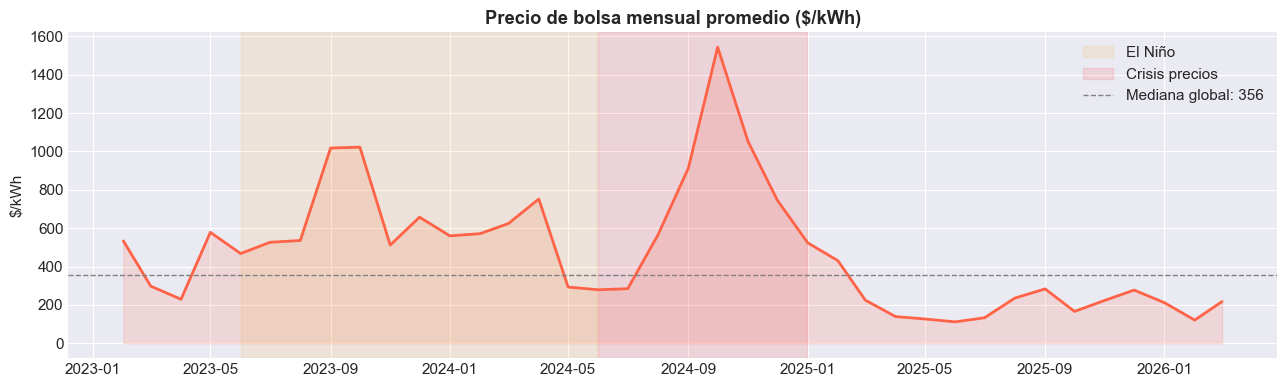

In [6]:
# Serie temporal del precio — se construye 'mensual' para uso posterior
dataset['year_month'] = dataset['date'].dt.to_period('M')
mensual = dataset.groupby('year_month').agg(
    precio=(TARGET, 'mean'),
    reservas=('reservas_pct', 'mean'),
).reset_index()
mensual['fecha'] = mensual['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mensual['fecha'], mensual['precio'], color='tomato', linewidth=2)
ax.fill_between(mensual['fecha'], mensual['precio'], alpha=0.15, color='tomato')
ax.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2024-05-31'), alpha=0.1, color='orange', label='El Niño')
ax.axvspan(pd.Timestamp('2024-06-01'), pd.Timestamp('2024-12-31'), alpha=0.1, color='red', label='Crisis precios')
ax.axhline(dataset[TARGET].median(), linestyle='--', color='gray', linewidth=1,
           label=f'Mediana global: {dataset[TARGET].median():.0f}')
ax.set_title('Precio de bolsa mensual promedio ($/kWh)', fontweight='bold')
ax.set_ylabel('$/kWh'); ax.legend()
plt.tight_layout()
plt.savefig('figures/serie_temporal_precio.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Verificar que el pico de 2024 es dato real, no error
print('=== TOP 10 PRECIOS MÁS ALTOS ===')
top10 = dataset[['date', TARGET, 'reservas_pct', 'ratio_hidro', 'gen_termica']].nlargest(10, TARGET)
display(top10)
print('\n→ El pico de sep-oct 2024 coincide con reservas mínimas y máxima generación térmica.')
print('→ Corresponde al fenómeno El Niño 2024. Es dato real, no error de captura.')

=== TOP 10 PRECIOS MÁS ALTOS ===


,date,precio_bolsa_kwh,reservas_pct,ratio_hidro,gen_termica
607,2024-09-30,"3,682.630",0.520,50.180,101384687
641,2024-11-03,"2,459.350",0.550,60.380,68778557
639,2024-11-01,"2,459.330",0.530,62.050,77716554
638,2024-10-31,"2,457.560",0.520,61.910,77518138
640,2024-11-02,"2,452.710",0.540,59.790,77505968
642,2024-11-04,"2,363.490",0.560,59.060,73054491
626,2024-10-19,"2,277.590",0.540,48.570,107805284
632,2024-10-25,"2,004.810",0.550,51.520,103460416
645,2024-11-07,"1,944.200",0.560,53.330,98898669
625,2024-10-18,"1,883.920",0.520,49.000,110459652



→ El pico de sep-oct 2024 coincide con reservas mínimas y máxima generación térmica.
→ Corresponde al fenómeno El Niño 2024. Es dato real, no error de captura.


---
## 6. EDA — Análisis de variables: relaciones, señal predictiva y selección <a name="eda"></a>

Este bloque sigue una narrativa en tres pasos:

1. **Relaciones entre variables** — detectar multicolinealidad, redundancia y cadenas causales
2. **Relaciones con el target** — identificar qué variables tienen señal predictiva real
3. **Evaluación de reducción** — probar si eliminar variables redundantes mejora o empeora el modelo

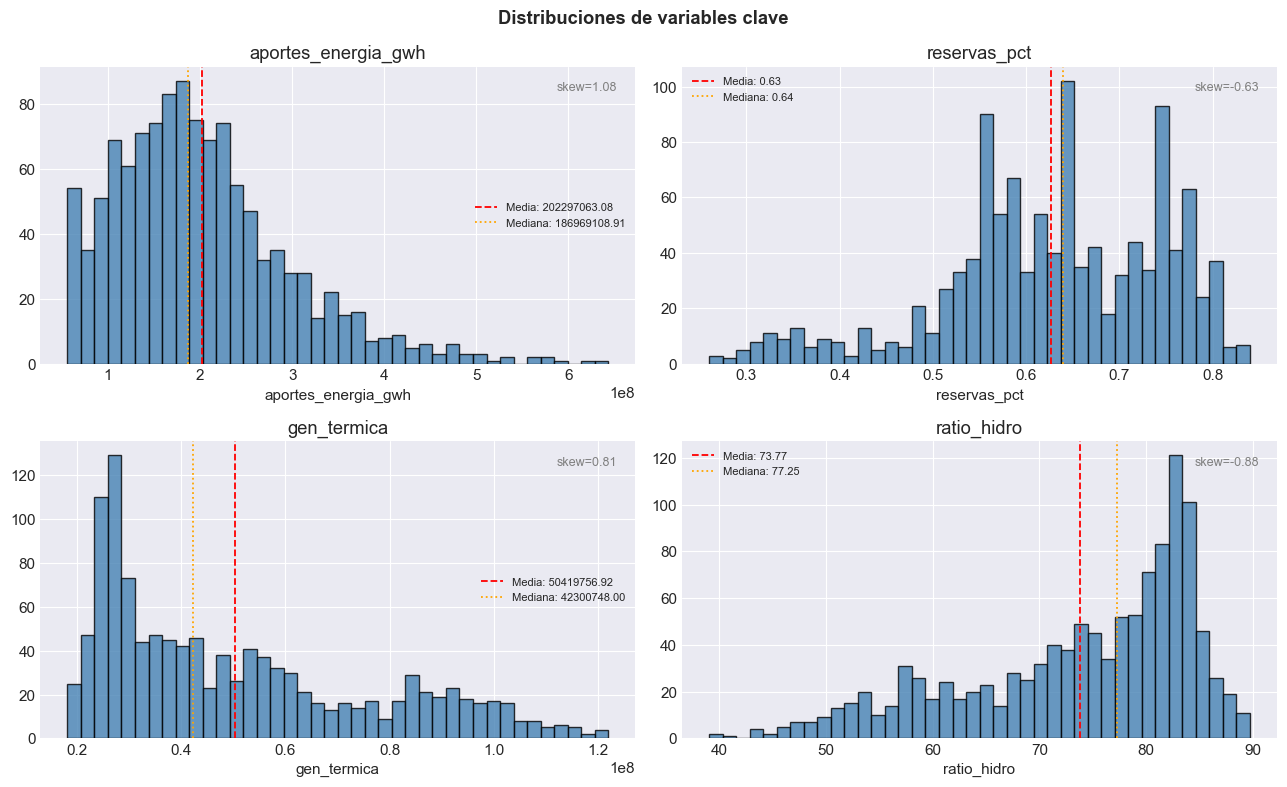

In [8]:
# Distribuciones de variables clave
vars_plot = ['aportes_energia_gwh', 'reservas_pct', 'gen_termica', 'ratio_hidro']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de variables clave', fontweight='bold')

for ax, col in zip(axes.flat, vars_plot):
    s = dataset[col]
    ax.hist(s, bins=40, edgecolor='black', alpha=0.8, color='steelblue')
    ax.axvline(s.mean(),   linestyle='--', linewidth=1.3, color='red',    label=f'Media: {s.mean():.2f}')
    ax.axvline(s.median(), linestyle=':',  linewidth=1.3, color='orange', label=f'Mediana: {s.median():.2f}')
    ax.set_title(col); ax.set_xlabel(col); ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f'skew={s.skew():.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('figures/distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()

### 6a. Relaciones entre variables

Antes de mirar qué predice el target, analizamos cómo se relacionan las variables entre sí. Esto revela:
- **Multicolinealidad**: features que dicen lo mismo y pueden desestabilizar modelos lineales
- **Cadenas causales**: cómo se propagan los efectos en el sistema
- **Redundancia**: variables que ya están implícitas en otras

> **Regla:** si dos features tienen |r| > 0.85, considerar cuál aporta más información única.

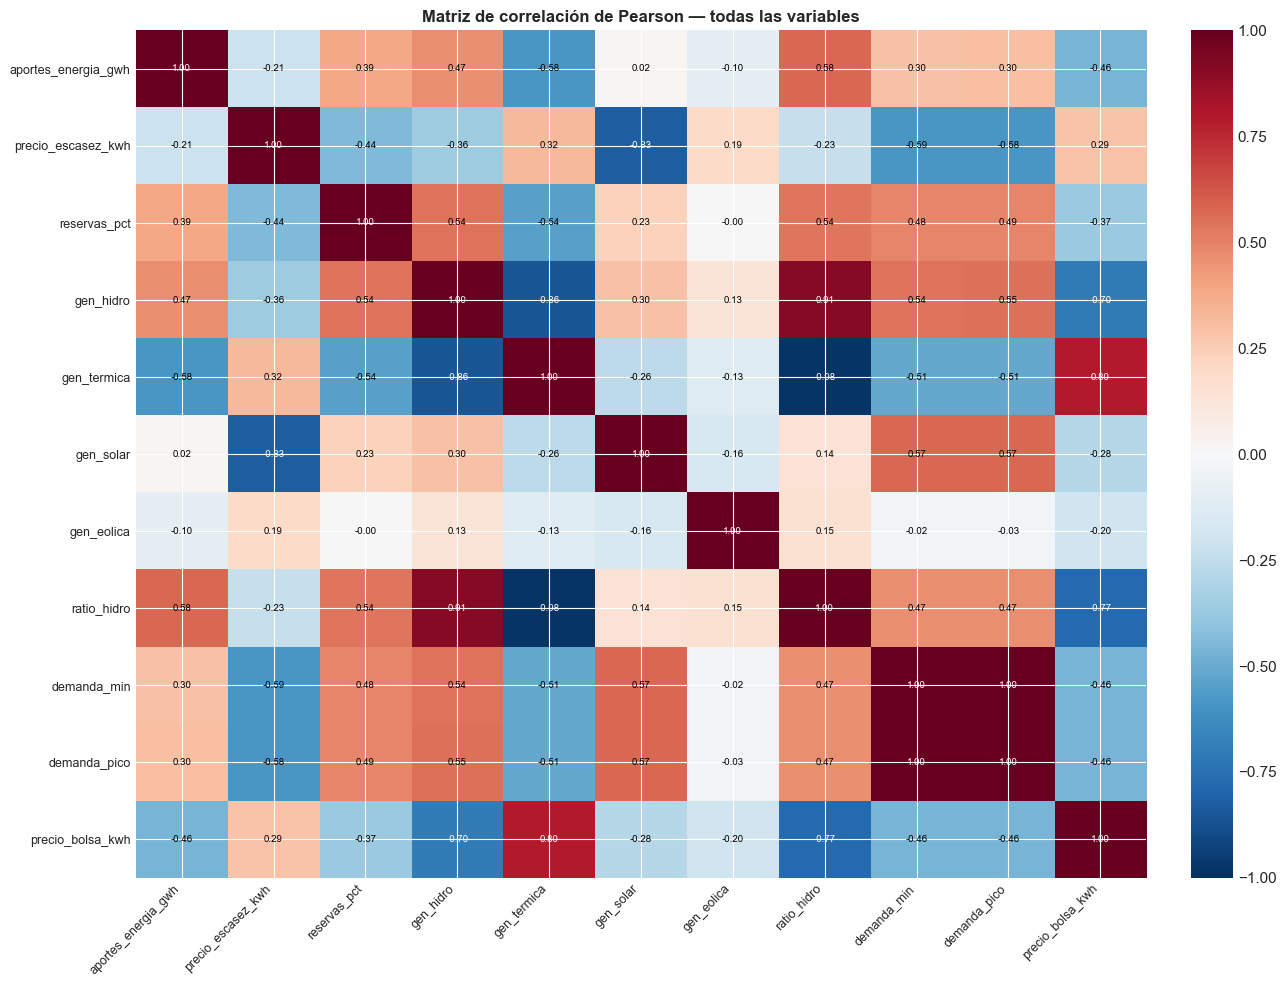

In [9]:
# Variables para el análisis entre features (sin target aún)
VARS_ANALISIS = [
    'aportes_energia_gwh', 'precio_escasez_kwh', 'reservas_pct',
    'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro',
    'demanda_min', 'demanda_pico', 'precio_bolsa_kwh'
]

corr_matrix = dataset[VARS_ANALISIS].corr()

# ── Heatmap completo ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr_matrix.values, aspect='auto', vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(VARS_ANALISIS)))
ax.set_xticklabels(VARS_ANALISIS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(VARS_ANALISIS)))
ax.set_yticklabels(VARS_ANALISIS, fontsize=9)
ax.set_title('Matriz de correlación de Pearson — todas las variables', fontweight='bold', fontsize=12)
for i in range(len(VARS_ANALISIS)):
    for j in range(len(VARS_ANALISIS)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)
plt.tight_layout()
plt.savefig('figures/heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Pares con alta correlación entre features ────────────────────────────
pairs = []
cols = [c for c in VARS_ANALISIS if c != TARGET]
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.loc[cols[i], cols[j]]
        if abs(r) > 0.70:
            pairs.append({'variable_1': cols[i], 'variable_2': cols[j], 'r': round(r, 4)})

pairs_df = pd.DataFrame(pairs).sort_values('r', key=abs, ascending=False)
print('=== PARES FEATURE-FEATURE CON |r| > 0.70 ===')
display(pairs_df)

print('\n→ gen_termica ↔ ratio_hidro: r=-0.98 — sustitución casi perfecta')
print('→ gen_hidro ↔ ratio_hidro:   r=+0.91 — miden la misma señal hídrica')
print('→ gen_hidro ↔ gen_termica:   r=-0.86 — consecuencia directa de la sustitución')
print('→ demanda_min ↔ demanda_pico: r=+0.999 — prácticamente la misma variable')

=== PARES FEATURE-FEATURE CON |r| > 0.70 ===


,variable_1,variable_2,r
4,demanda_min,demanda_pico,0.999
3,gen_termica,ratio_hidro,-0.980
2,gen_hidro,ratio_hidro,0.907
1,gen_hidro,gen_termica,-0.859
0,precio_escasez_kwh,gen_solar,-0.827



→ gen_termica ↔ ratio_hidro: r=-0.98 — sustitución casi perfecta
→ gen_hidro ↔ ratio_hidro:   r=+0.91 — miden la misma señal hídrica
→ gen_hidro ↔ gen_termica:   r=-0.86 — consecuencia directa de la sustitución
→ demanda_min ↔ demanda_pico: r=+0.999 — prácticamente la misma variable


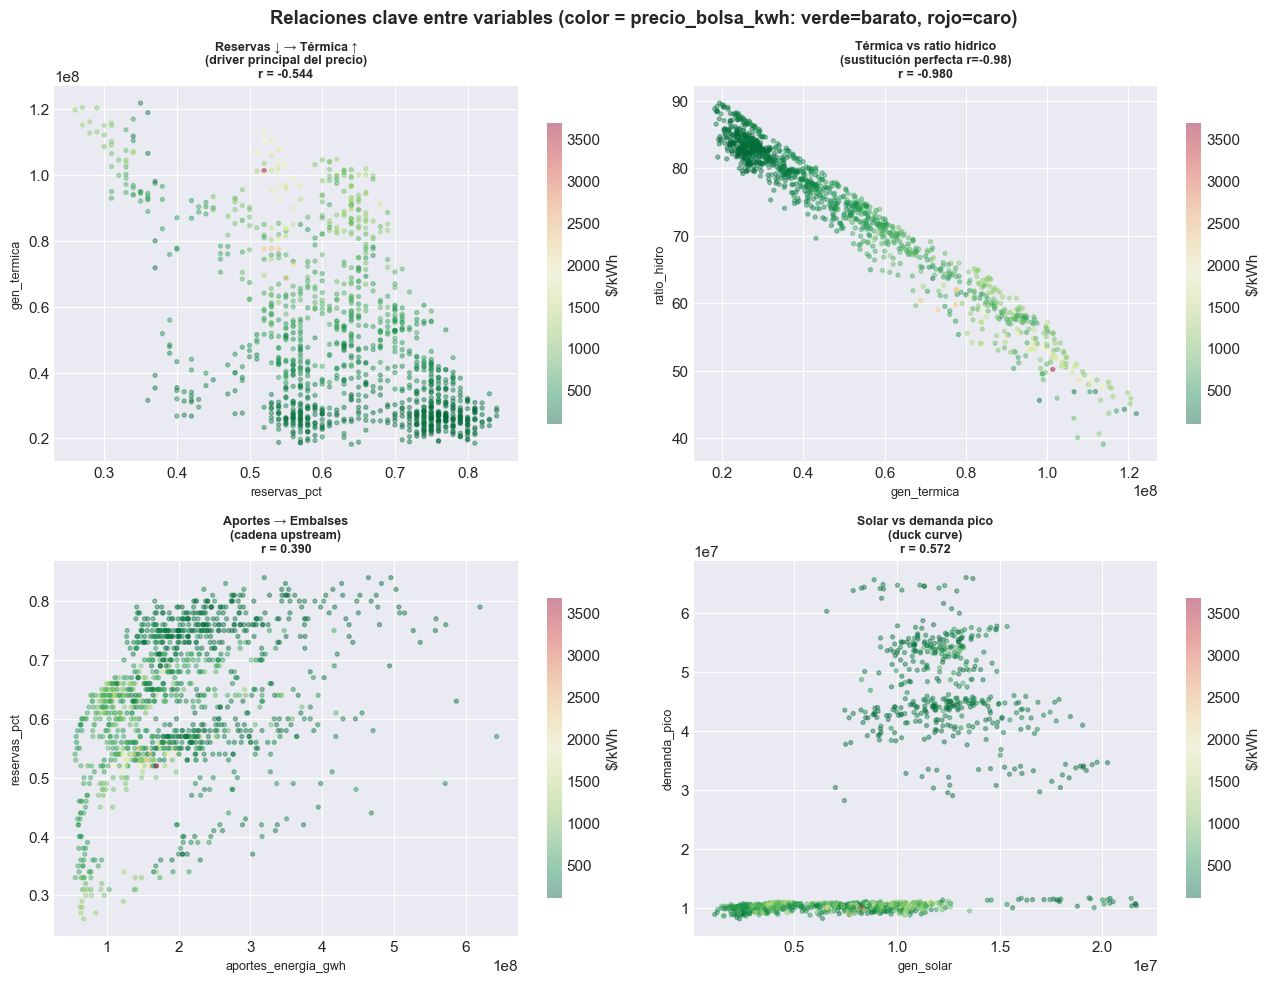

In [11]:
# ── Scatter plots de las cadenas causales del dominio ────────────────────
key_pairs = [
    ('reservas_pct',        'gen_termica',   'Reservas ↓ → Térmica ↑\n(driver principal del precio)'),
    ('gen_termica',         'ratio_hidro',   'Térmica vs ratio hídrico\n(sustitución perfecta r=-0.98)'),
    ('aportes_energia_gwh', 'reservas_pct',  'Aportes → Embalses\n(cadena upstream)'),
    ('gen_solar',           'demanda_pico',  'Solar vs demanda pico\n(duck curve)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Relaciones clave entre variables (color = precio_bolsa_kwh: verde=barato, rojo=caro)',
             fontweight='bold')
for ax, (vx, vy, titulo) in zip(axes.flat, key_pairs):
    r = dataset[[vx, vy]].corr().iloc[0, 1]
    sc = ax.scatter(dataset[vx], dataset[vy], c=dataset[TARGET],
                    cmap='RdYlGn_r', alpha=0.4, s=8)
    plt.colorbar(sc, ax=ax, label='$/kWh', shrink=0.8)
    ax.set_xlabel(vx, fontsize=9); ax.set_ylabel(vy, fontsize=9)
    ax.set_title(f'{titulo}\nr = {r:.3f}', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/scatter_relaciones_variables.png', dpi=150, bbox_inches='tight')
plt.show()

**Cadena causal del sistema eléctrico colombiano:**

```
aportes_energia_gwh → reservas_pct → gen_termica → precio_bolsa_kwh
       r=+0.39              r=-0.54       r=+0.795
```

La señal se **amplifica** a lo largo de la cadena. La multicolinealidad entre `gen_termica`, `gen_hidro` y `ratio_hidro` no es ruido — refleja la física del sistema: son tres formas de medir el mismo fenómeno de sustitución hídrica-térmica.

---
## 4b. Herramientas visuales del EDA — Boxplot, Q-Q Plot y Violin

Herramientas visuales utilizadas:

- **Boxplot:** resumen de 5 números + detección visual de outliers
- **Q-Q Plot:** verificar si la transformación log produce normalidad
- **Violin Plot:** comparar distribuciones entre grupos — revela el cambio de régimen

> *"Siempre acompañar el test con herramientas visuales (histograma, Q-Q plot)."*  

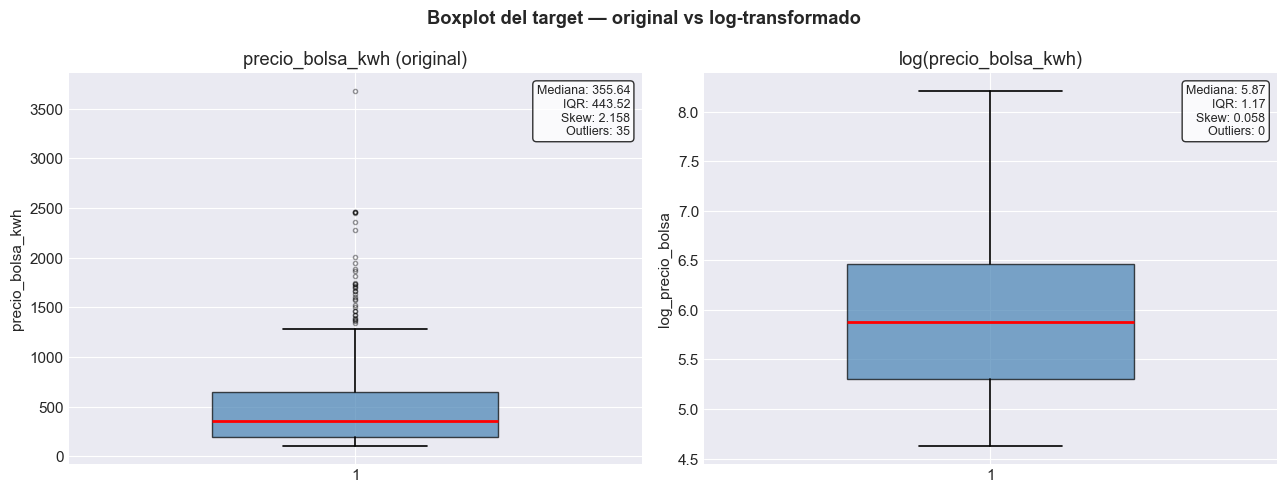

→ Los outliers del original son datos reales del El Niño 2024.
→ La transformación log los comprime y hace la distribución simétrica.


In [12]:
# ── Boxplot: target original vs log-transformado ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Boxplot del target — original vs log-transformado', fontweight='bold')

for ax, col, titulo in zip(axes,
    [TARGET, 'log_precio_bolsa'],
    ['precio_bolsa_kwh (original)', 'log(precio_bolsa_kwh)']):
    s = dataset[col]
    ax.boxplot(s, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.4, color='tomato'),
               whiskerprops=dict(linewidth=1.2), capprops=dict(linewidth=1.2))
    ax.set_title(titulo); ax.set_ylabel(col)
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    outliers = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()
    ax.text(0.98, 0.97,
        f'Mediana: {s.median():.2f}\nIQR: {iqr:.2f}\nSkew: {s.skew():.3f}\nOutliers: {outliers}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/boxplot_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Los outliers del original son datos reales del El Niño 2024.')
print('→ La transformación log los comprime y hace la distribución simétrica.')

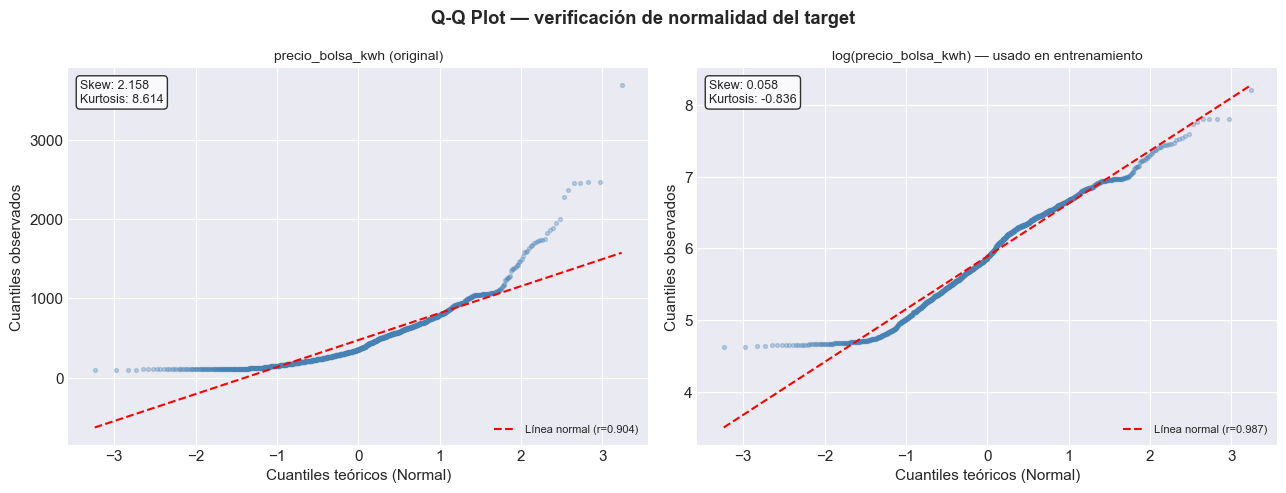

→ Original: puntos alejados de la diagonal → no normal (skew=2.158)
→ Log: puntos siguen la diagonal → distribución aproximadamente normal
→ La transformación log está justificada estadísticamente.


In [13]:
# ── Q-Q Plot: verificar normalidad después de la transformación log ───────
from scipy import stats as scipy_stats

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q-Q Plot — verificación de normalidad del target', fontweight='bold')

for ax, col, titulo in zip(axes,
    [TARGET, 'log_precio_bolsa'],
    ['precio_bolsa_kwh (original)', 'log(precio_bolsa_kwh) — usado en entrenamiento']):
    s = dataset[col].dropna()
    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(s, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=8, color='steelblue')
    ax.plot([osm[0], osm[-1]], [slope*osm[0]+intercept, slope*osm[-1]+intercept],
            'r--', linewidth=1.5, label=f'Línea normal (r={r:.3f})')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Cuantiles teóricos (Normal)'); ax.set_ylabel('Cuantiles observados')
    ax.legend(fontsize=8)
    ax.text(0.02, 0.97, f'Skew: {s.skew():.3f}\nKurtosis: {s.kurtosis():.3f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/qqplot_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Original: puntos alejados de la diagonal → no normal (skew=2.158)')
print('→ Log: puntos siguen la diagonal → distribución aproximadamente normal')
print('→ La transformación log está justificada estadísticamente.')

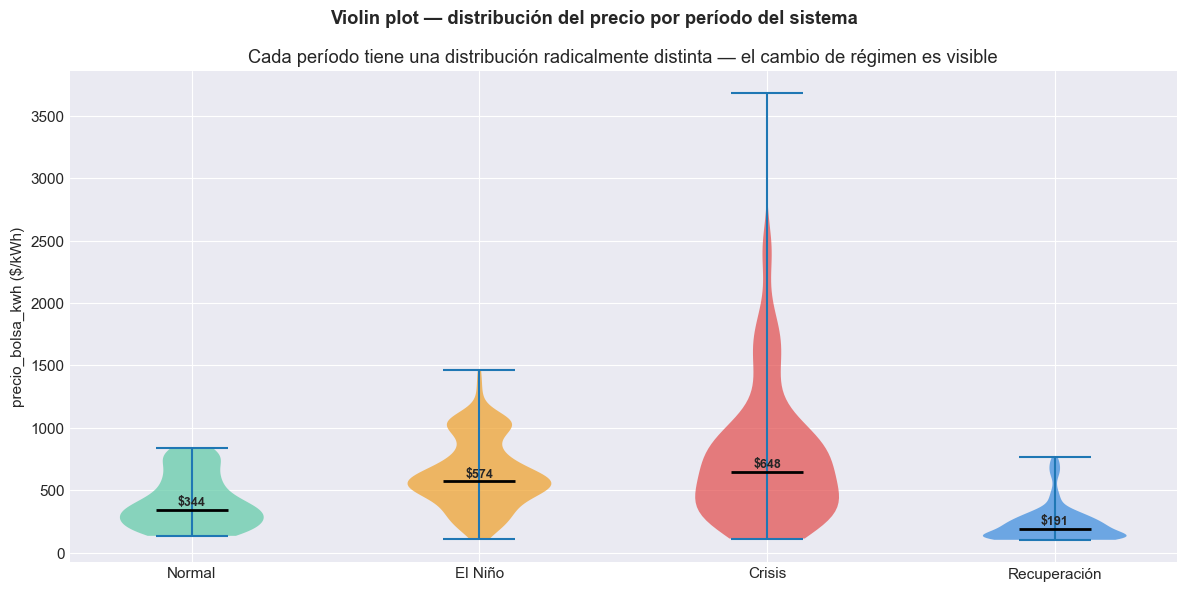

→ El violin muestra que la Crisis tiene cola derecha brutal.
→ Recuperación es compacta y baja — régimen completamente diferente.
→ Justifica visualmente por qué el modelo tiene dificultad para generalizar.


In [14]:
# ── Violin plot: distribución del precio por período ─────────────────────
dataset['periodo'] = 'Normal'
dataset.loc[(dataset['date']>='2023-06-01')&(dataset['date']<='2024-05-31'),'periodo'] = 'El Niño'
dataset.loc[(dataset['date']>='2024-06-01')&(dataset['date']<='2024-12-31'),'periodo'] = 'Crisis'
dataset.loc[dataset['date']>='2025-01-01','periodo'] = 'Recuperación'

orden = ['Normal', 'El Niño', 'Crisis', 'Recuperación']
colores_v = ['#5DCAA5', '#EF9F27', '#E24B4A', '#378ADD']
data_v = [dataset[dataset['periodo']==p][TARGET].values for p in orden]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Violin plot — distribución del precio por período del sistema',
             fontweight='bold')
parts = ax.violinplot(data_v, positions=range(len(orden)),
                      showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], colores_v):
    pc.set_facecolor(color); pc.set_alpha(0.7)
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, fontsize=11)
ax.set_ylabel('precio_bolsa_kwh ($/kWh)')
ax.set_title('Cada período tiene una distribución radicalmente distinta — el cambio de régimen es visible')
for i, p in enumerate(orden):
    med = np.median(data_v[i])
    ax.text(i, med+30, f'${med:.0f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/violin_por_periodo.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ El violin muestra que la Crisis tiene cola derecha brutal.')
print('→ Recuperación es compacta y baja — régimen completamente diferente.')
print('→ Justifica visualmente por qué el modelo tiene dificultad para generalizar.')

### 6b. Relaciones con el target

Con la estructura entre features clara, ahora medimos cuánta señal predictiva aporta cada variable sobre `precio_bolsa_kwh`.

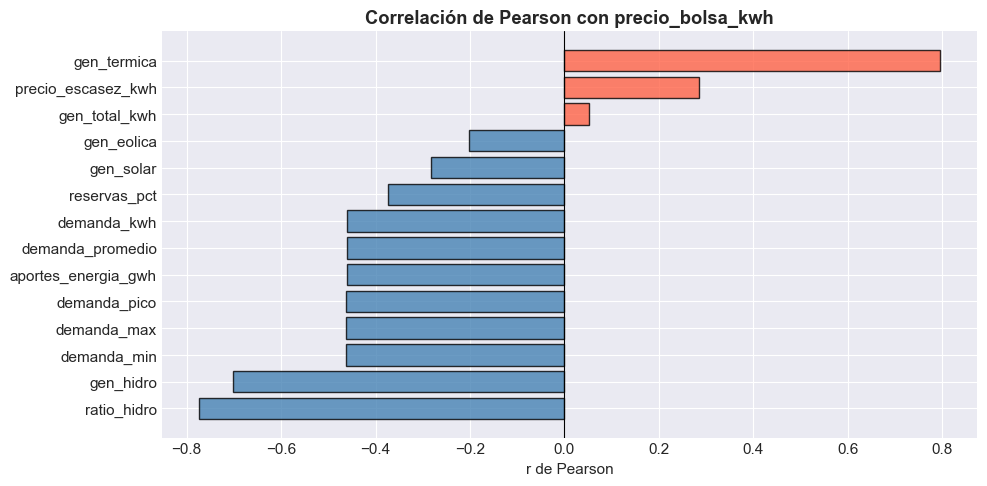


=== CORRELACIONES CON EL TARGET ===
gen_termica            0.795
precio_escasez_kwh     0.285
gen_total_kwh          0.051
gen_eolica            -0.201
gen_solar             -0.282
reservas_pct          -0.374
demanda_kwh           -0.461
demanda_promedio      -0.461
aportes_energia_gwh   -0.461
demanda_pico          -0.462
demanda_max           -0.462
demanda_min           -0.464
gen_hidro             -0.701
ratio_hidro           -0.774


In [15]:
# Correlaciones con el target
excluir = ['date', 'year_month', 'log_precio_bolsa', 'periodo',
           'diff_max_pico', 'dias_desde_inicio', 'solar_tendencia',
           'solar_detrended', 'participacion_solar', 'solar_vs_hidro',
           'termica_evitada_ref', 'solar_momentum_30d']
cols_corr = [c for c in dataset.columns if c not in excluir]
corr = dataset[cols_corr].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Correlación de Pearson con {TARGET}', fontweight='bold')
ax.set_xlabel('r de Pearson'); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/correlaciones_target.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CORRELACIONES CON EL TARGET ===')
print(corr.round(3).to_string())

**Lectura de las correlaciones con el target:**

- `gen_termica` (+0.795) y `ratio_hidro` (−0.774): las dos señales más fuertes — y como vimos en 6a, tienen r=−0.98 entre sí
- `gen_hidro` (−0.701): tercera señal más fuerte, pero r=+0.91 con `ratio_hidro` — información mayormente redundante
- `gen_solar` (−0.282) y `gen_eolica` (−0.201): señal débil directa, pero capturan la transición energética estructural

**Pregunta que surge:** si `gen_termica`, `gen_hidro` y `ratio_hidro` son tan redundantes entre sí, ¿podríamos eliminar algunas y mantener el mismo poder predictivo?

In [16]:
# Evolución de la generación solar
solar_anual = dataset.groupby(dataset['date'].dt.year).agg(
    solar_media=('gen_solar', 'mean'),
    pct_solar=('gen_solar', lambda x: (x / dataset.loc[x.index, 'gen_total_kwh']).mean() * 100)
).round(2)

print('=== EXPANSIÓN SOLAR — TENDENCIA ESTRUCTURAL ===')
print(solar_anual.to_string())
print('\n→ La generación solar se multiplicó ~5x en 3 años.')
print('→ gen_solar tiene tendencia no estacionaria: se conserva como feature con esta limitación documentada.')

=== EXPANSIÓN SOLAR — TENDENCIA ESTRUCTURAL ===
        solar_media  pct_solar
date                          
2023  3,411,587.200      1.530
2024  9,033,202.360      3.980
2025 11,941,276.050      5.170
2026 16,200,948.110      6.900

→ La generación solar se multiplicó ~5x en 3 años.
→ gen_solar tiene tendencia no estacionaria: se conserva como feature con esta limitación documentada.


### 6c. Evaluación de reducción de features

Con base en el análisis de redundancia de 6a, proponemos un **set reducido** que elimina las variables más redundantes:

| Eliminada | Razón |
|---|---|
| `gen_termica` | r=−0.98 con `ratio_hidro`; ya está capturada en `estres_hidrico` |
| `gen_hidro` | r=+0.91 con `ratio_hidro`; ya está dentro de `gen_renovable` |
| `demanda_min` | r=+0.999 con `demanda_pico`; ya está dentro de `efecto_solar_demanda` |

Comparamos tres sets contra el mismo modelo Ridge para decidir cuál usar.

In [17]:
# ── Definición de los tres sets ──────────────────────────────────────────
FEATURES_ACTUAL = [
    'aportes_energia_gwh', 'precio_escasez_kwh', 'reservas_pct',
    'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro',
    'demanda_min', 'demanda_pico',
    'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable',
]

FEATURES_REDUCIDO = [
    'aportes_energia_gwh', 'reservas_pct', 'ratio_hidro',
    'gen_solar', 'gen_eolica', 'demanda_pico',
    'precio_escasez_kwh',
    'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable',
]

FEATURES_MINIMO = [f for f in FEATURES_REDUCIDO if f != 'gen_eolica']

print(f'Set actual  : {len(FEATURES_ACTUAL):2d} features — {FEATURES_ACTUAL}')
print(f'Set reducido: {len(FEATURES_REDUCIDO):2d} features — {FEATURES_REDUCIDO}')
print(f'Set mínimo  : {len(FEATURES_MINIMO):2d} features — {FEATURES_MINIMO}')
print(f'\nEliminadas en reducido: {[f for f in FEATURES_ACTUAL if f not in FEATURES_REDUCIDO]}')

Set actual  : 13 features — ['aportes_energia_gwh', 'precio_escasez_kwh', 'reservas_pct', 'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro', 'demanda_min', 'demanda_pico', 'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable']
Set reducido: 10 features — ['aportes_energia_gwh', 'reservas_pct', 'ratio_hidro', 'gen_solar', 'gen_eolica', 'demanda_pico', 'precio_escasez_kwh', 'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable']
Set mínimo  :  9 features — ['aportes_energia_gwh', 'reservas_pct', 'ratio_hidro', 'gen_solar', 'demanda_pico', 'precio_escasez_kwh', 'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable']

Eliminadas en reducido: ['gen_hidro', 'gen_termica', 'demanda_min']


In [18]:
# ── Comparación con Ridge — mismo modelo, distintos sets ─────────────────
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_set(features, name, train_df, test_df, target_log, target_orig):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   Ridge(alpha=1.0)),
    ])
    pipe.fit(train_df[features], train_df[target_log])
    pred = pipe.predict(test_df[features])
    rmse = np.sqrt(mean_squared_error(np.exp(test_df[target_log]), np.exp(pred)))
    mae  = mean_absolute_error(np.exp(test_df[target_log]), np.exp(pred))
    r2   = r2_score(test_df[target_log], pred)
    return {'set': name, 'n_features': len(features),
            'rmse_orig': round(rmse, 1), 'mae_orig': round(mae, 1), 'r2_log': round(r2, 4)}

# Necesitamos train y test con features engineered — los creamos aquí
def add_engineered_features(df):
    out = df.copy()
    out['estres_hidrico']       = out['gen_termica'] / (out['reservas_pct'] + 0.01)
    out['efecto_solar_demanda'] = out['demanda_pico'] - out['demanda_min']
    out['gen_renovable']        = out['gen_hidro'] + out['gen_solar'] + out['gen_eolica']
    return out.replace([np.inf, -np.inf], np.nan)

FECHA_CORTE = '2025-03-31'
TARGET_LOG  = 'log_precio_bolsa'
train_eval = add_engineered_features(dataset[dataset['date'] <= FECHA_CORTE].copy())
test_eval  = add_engineered_features(dataset[dataset['date'] >  FECHA_CORTE].copy())
train_eval[TARGET_LOG] = np.log(train_eval[TARGET])
test_eval[TARGET_LOG]  = np.log(test_eval[TARGET])

resultados_sets = [
    eval_set(FEATURES_ACTUAL,   'Set actual (13)',   train_eval, test_eval, TARGET_LOG, TARGET),
    eval_set(FEATURES_REDUCIDO, 'Set reducido (10)', train_eval, test_eval, TARGET_LOG, TARGET),
    eval_set(FEATURES_MINIMO,   'Set mínimo (9)',    train_eval, test_eval, TARGET_LOG, TARGET),
]

comp_df = pd.DataFrame(resultados_sets)
print('=== COMPARACIÓN DE SETS DE FEATURES — Ridge alpha=1.0 ===')
display(comp_df)

=== COMPARACIÓN DE SETS DE FEATURES — Ridge alpha=1.0 ===


,set,n_features,rmse_orig,mae_orig,r2_log
0,Set actual (13),13,101.000,89.800,-0.662
1,Set reducido (10),10,115.200,104.100,-0.966
2,Set mínimo (9),9,125.600,114.900,-1.242


### 6e. Tipos de correlación — Pearson vs Spearman y forma funcional

El curso distingue tres tipos de correlación (`02_mla_eda.pdf`):
- **Pearson:** mide relaciones **lineales**. Sensible a outliers.
- **Spearman:** basada en rangos. Detecta relaciones **monótonas no lineales**. Robusta a outliers.

Comparar ambas revela si los outliers del El Niño distorsionan la correlación lineal.

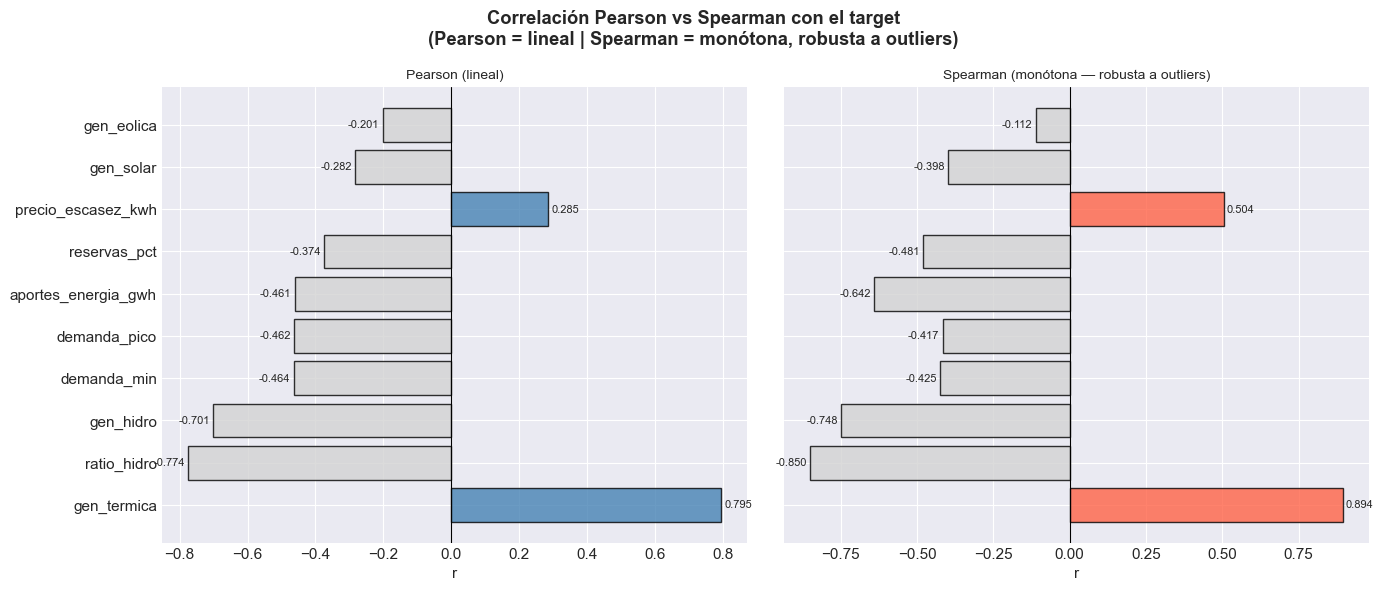


=== DIFERENCIAS PEARSON vs SPEARMAN ===
  gen_termica               Pearson=+0.795  Spearman=+0.894  ← Spearman detecta más señal (relación no lineal)
  ratio_hidro               Pearson=-0.774  Spearman=-0.850  ← Spearman detecta más señal (relación no lineal)
  gen_hidro                 Pearson=-0.701  Spearman=-0.748  
  demanda_min               Pearson=-0.464  Spearman=-0.425  
  demanda_pico              Pearson=-0.462  Spearman=-0.417  
  aportes_energia_gwh       Pearson=-0.461  Spearman=-0.642  ← Spearman detecta más señal (relación no lineal)
  reservas_pct              Pearson=-0.374  Spearman=-0.481  ← Spearman detecta más señal (relación no lineal)
  precio_escasez_kwh        Pearson=+0.285  Spearman=+0.504  ← Spearman detecta más señal (relación no lineal)
  gen_solar                 Pearson=-0.282  Spearman=-0.398  ← Spearman detecta más señal (relación no lineal)
  gen_eolica                Pearson=-0.201  Spearman=-0.112  


In [19]:
# ── Pearson vs Spearman ───────────────────────────────────────────────────
cols_corr2 = ['aportes_energia_gwh','precio_escasez_kwh','reservas_pct',
              'gen_hidro','gen_termica','gen_solar','gen_eolica','ratio_hidro',
              'demanda_min','demanda_pico']

pearson_r  = [dataset[c].corr(dataset[TARGET], method='pearson')  for c in cols_corr2]
spearman_r = [dataset[c].corr(dataset[TARGET], method='spearman') for c in cols_corr2]

idx = np.argsort(np.abs(pearson_r))[::-1]
cols_s = [cols_corr2[i] for i in idx]
p_s    = [pearson_r[i]  for i in idx]
sp_s   = [spearman_r[i] for i in idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Correlación Pearson vs Spearman con el target\n'
             '(Pearson = lineal | Spearman = monótona, robusta a outliers)',
             fontweight='bold')

for ax, vals, titulo, color in zip(axes,
    [p_s, sp_s],
    ['Pearson (lineal)', 'Spearman (monótona — robusta a outliers)'],
    ['steelblue', 'tomato']):
    clrs = [color if v > 0 else 'lightgray' for v in vals]
    ax.barh(cols_s, vals, color=clrs, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=10); ax.set_xlabel('r'); ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v+(0.01 if v>=0 else -0.01), i, f'{v:.3f}', va='center',
                ha='left' if v>=0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('figures/correlacion_pearson_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== DIFERENCIAS PEARSON vs SPEARMAN ===')
for c, p, s in zip(cols_s, p_s, sp_s):
    diff = abs(s) - abs(p)
    nota = '← Spearman detecta más señal (relación no lineal)' if diff > 0.05 else ''
    print(f'  {c:<25} Pearson={p:+.3f}  Spearman={s:+.3f}  {nota}')

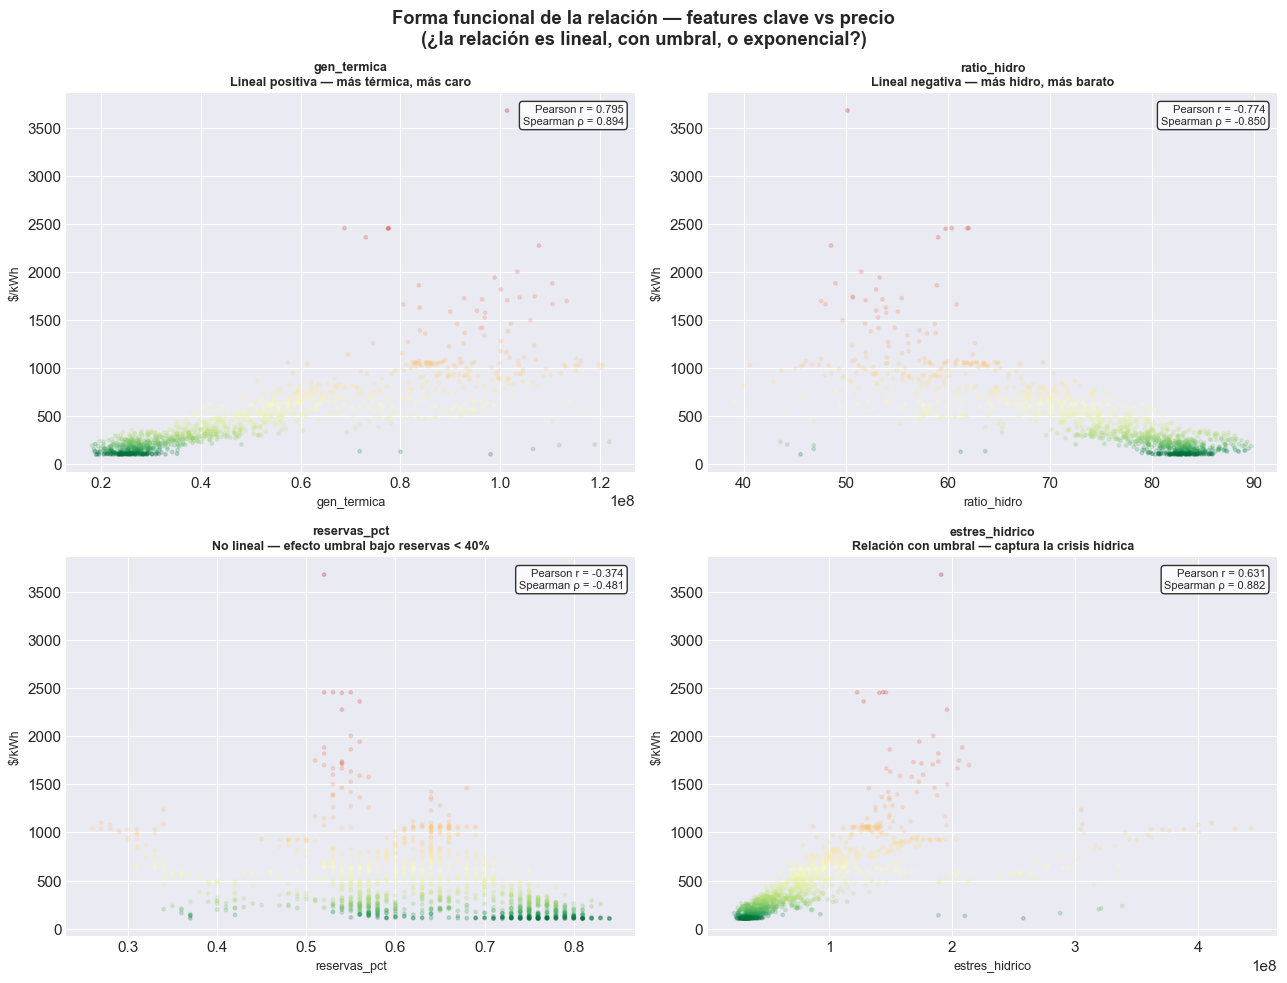

→ reservas_pct tiene r_Pearson=-0.37 pero el scatter muestra un umbral claro.
→ Esto justifica estres_hidrico: captura ese umbral no lineal en una sola variable.


In [20]:
# ── Forma funcional: ¿lineal, con umbral, o exponencial? ─────────────────
dataset_ef = dataset.copy()
dataset_ef['estres_hidrico'] = dataset_ef['gen_termica'] / (dataset_ef['reservas_pct'] + 0.01)
dataset_ef['log_p'] = np.log(dataset_ef[TARGET])

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Forma funcional de la relación — features clave vs precio\n'
             '(¿la relación es lineal, con umbral, o exponencial?)', fontweight='bold')

pares_ff = [
    ('gen_termica',   'Lineal positiva — más térmica, más caro'),
    ('ratio_hidro',   'Lineal negativa — más hidro, más barato'),
    ('reservas_pct',  'No lineal — efecto umbral bajo reservas < 40%'),
    ('estres_hidrico','Relación con umbral — captura la crisis hídrica'),
]

for ax, (feat, desc) in zip(axes.flat, pares_ff):
    y = dataset_ef[TARGET].values
    x = dataset_ef[feat].values
    mask = ~np.isnan(x)
    r_p = np.corrcoef(x[mask], y[mask])[0,1]
    r_s = pd.Series(x).corr(pd.Series(y), method='spearman')
    ax.scatter(x, y, alpha=0.2, s=6, c=dataset_ef['log_p'], cmap='RdYlGn_r')
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('$/kWh', fontsize=9)
    ax.set_title(f'{feat}\n{desc}', fontsize=9, fontweight='bold')
    ax.text(0.98, 0.97, f'Pearson r = {r_p:.3f}\nSpearman ρ = {r_s:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/scatter_forma_funcional.png', dpi=150, bbox_inches='tight')
plt.show()

print('→ reservas_pct tiene r_Pearson=-0.37 pero el scatter muestra un umbral claro.')
print('→ Esto justifica estres_hidrico: captura ese umbral no lineal en una sola variable.')

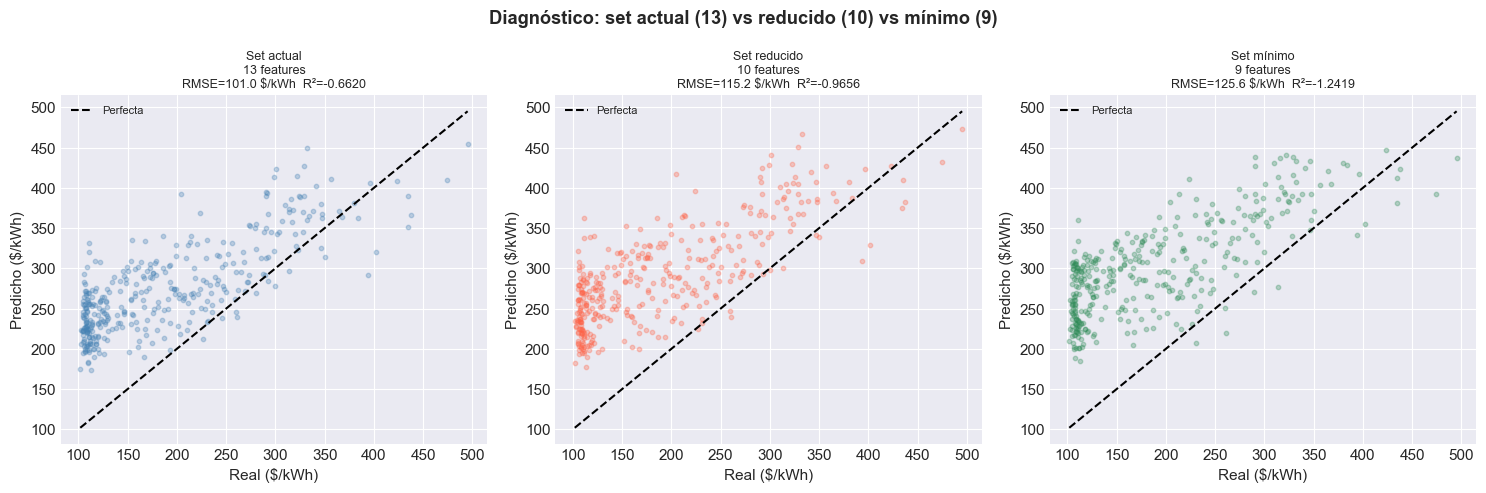

In [21]:
# ── Visualización comparativa ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Diagnóstico: set actual (13) vs reducido (10) vs mínimo (9)', fontweight='bold')

sets_viz = [
    (FEATURES_ACTUAL,   'Set actual\n13 features',   'steelblue'),
    (FEATURES_REDUCIDO, 'Set reducido\n10 features', 'tomato'),
    (FEATURES_MINIMO,   'Set mínimo\n9 features',    'seagreen'),
]

for ax, (feats, label, color) in zip(axes, sets_viz):
    pipe = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('model', Ridge(alpha=1.0))])
    pipe.fit(train_eval[feats], train_eval[TARGET_LOG])
    pred = pipe.predict(test_eval[feats])
    y_pred = np.exp(pred); y_true = test_eval[TARGET].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(test_eval[TARGET_LOG], pred)
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color=color)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'k--', linewidth=1.5, label='Perfecta')
    ax.set_title(f'{label}\nRMSE={rmse:,.1f} $/kWh  R²={r2:.4f}', fontsize=9)
    ax.set_xlabel('Real ($/kWh)'); ax.set_ylabel('Predicho ($/kWh)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/comparacion_sets_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusión de la evaluación:**

| Set | Features | RMSE (\$/kWh) | R² (log) |
|---|---|---|---|
| Actual | 13 | **101.0** | **−0.66** |
| Reducido | 10 | 115.2 | −0.97 |
| Mínimo | 9 | 125.6 | −1.24 |

**El set actual (13 features) produce el mejor resultado.** Eliminar `gen_termica` y `gen_hidro` empeora el RMSE en ~14% aunque parezcan redundantes con `ratio_hidro`.

**¿Por qué?** `ratio_hidro` dice *qué porcentaje* es hídrico, pero `gen_termica` dice *cuántos kWh absolutos* de térmica se despacharon — son dos dimensiones distintas del mismo fenómeno. **Ridge maneja la multicolinealidad con regularización**, por lo que no necesitamos eliminar variables para proteger el modelo.

> **Decisión final: se conservan los 13 features.**  
> Para la Entrega 2 (Random Forest, GBM) se evaluará si el set reducido mejora en modelos basados en árboles, donde la redundancia puede desperdiciar splits.

---
## 7. EDA — Fenómeno El Niño 2023-2024 <a name="nino"></a>

In [22]:
# Estadísticas por período
dataset['periodo'] = 'Normal'
dataset.loc[(dataset['date'] >= '2023-06-01') & (dataset['date'] <= '2024-05-31'), 'periodo'] = 'El Niño'
dataset.loc[(dataset['date'] >= '2024-06-01') & (dataset['date'] <= '2024-12-31'), 'periodo'] = 'Crisis precios'
dataset.loc[dataset['date'] >= '2025-01-01', 'periodo'] = 'Recuperación'

resumen = dataset.groupby('periodo').agg(
    dias=('date', 'count'),
    precio_medio=(TARGET, 'mean'),
    precio_max=(TARGET, 'max'),
    reservas_media=('reservas_pct', 'mean'),
    reservas_min=('reservas_pct', 'min'),
    ratio_hidro=('ratio_hidro', 'mean'),
).round(2)

orden = ['Normal', 'El Niño', 'Crisis precios', 'Recuperación']
print('=== IMPACTO DEL FENÓMENO EL NIÑO ===')
display(resumen.reindex(orden))

=== IMPACTO DEL FENÓMENO EL NIÑO ===


,dias,precio_medio,precio_max,reservas_media,reservas_min,ratio_hidro
periodo,,,,,,
Normal,120,408.410,837.580,0.580,0.520,81.530
El Niño,366,628.120,"1,460.850",0.570,0.260,66.300
Crisis precios,214,769.650,"3,682.630",0.560,0.450,67.650
Recuperación,455,228.370,769.280,0.710,0.520,80.610


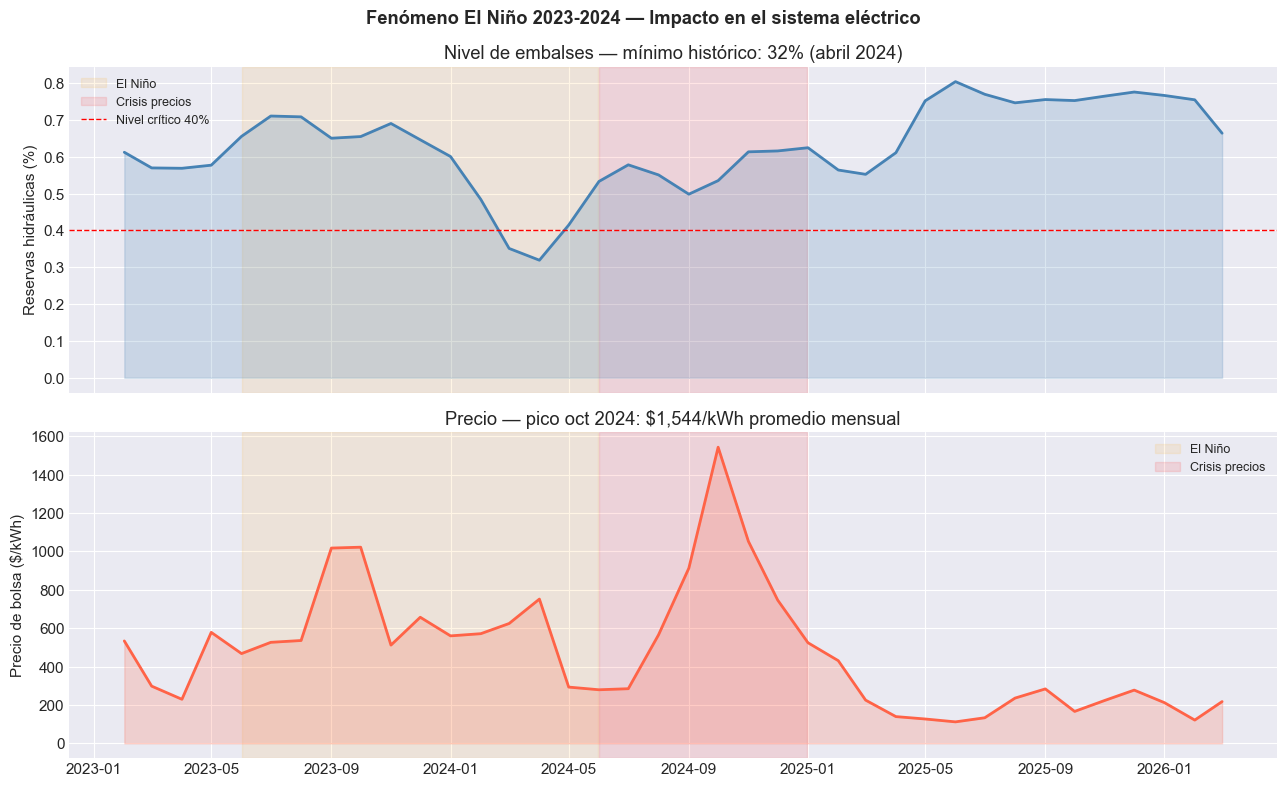

In [23]:
# Visualización: reservas y precio durante El Niño
# 'mensual' fue construido en la sección 5
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Fenómeno El Niño 2023-2024 — Impacto en el sistema eléctrico', fontweight='bold')

for ax in axes:
    ax.axvspan(pd.Timestamp('2023-06-01'), pd.Timestamp('2024-05-31'), alpha=0.1, color='orange', label='El Niño')
    ax.axvspan(pd.Timestamp('2024-06-01'), pd.Timestamp('2024-12-31'), alpha=0.1, color='red', label='Crisis precios')

axes[0].plot(mensual['fecha'], mensual['reservas'], color='steelblue', linewidth=2)
axes[0].axhline(0.40, linestyle='--', color='red', linewidth=1, label='Nivel crítico 40%')
axes[0].fill_between(mensual['fecha'], mensual['reservas'], alpha=0.2, color='steelblue')
axes[0].set_ylabel('Reservas hidráulicas (%)'); axes[0].set_title('Nivel de embalses — mínimo histórico: 32% (abril 2024)')
axes[0].legend(fontsize=9)

axes[1].plot(mensual['fecha'], mensual['precio'], color='tomato', linewidth=2)
axes[1].fill_between(mensual['fecha'], mensual['precio'], alpha=0.2, color='tomato')
axes[1].set_ylabel('Precio de bolsa ($/kWh)'); axes[1].set_title('Precio — pico oct 2024: $1,544/kWh promedio mensual')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/fenomeno_nino.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Análisis de redundancia <a name="redundancia"></a>

In [24]:
# Verificar redundancia en columnas de demanda
cols_demanda = ['demanda_kwh', 'demanda_max', 'demanda_min', 'demanda_promedio', 'demanda_pico']
print('=== CORRELACIÓN ENTRE VARIABLES DE DEMANDA ===')
display(dataset[cols_demanda].corr().round(4))

print(f'\n¿demanda_kwh == demanda_promedio? {(dataset["demanda_kwh"] == dataset["demanda_promedio"]).all()}')

suma = dataset['gen_hidro'] + dataset['gen_termica'] + dataset['gen_solar'] + dataset['gen_eolica']
print(f'\nDiferencia máxima gen_total vs suma componentes: {(dataset["gen_total_kwh"] - suma).abs().max()}')
print(f'Correlación gen_total con target: {dataset["gen_total_kwh"].corr(dataset[TARGET]):.4f}')

dataset['diff_max_pico'] = dataset['demanda_max'] - dataset['demanda_pico']
print(f'\nCorrelación (demanda_max - demanda_pico) vs gen_solar: {dataset["diff_max_pico"].corr(dataset["gen_solar"]):.4f}')
print('→ La diferencia crece con la solar (duck curve). demanda_pico ≠ demanda_max.')

=== CORRELACIÓN ENTRE VARIABLES DE DEMANDA ===


,demanda_kwh,demanda_max,demanda_min,demanda_promedio,demanda_pico
demanda_kwh,1.000,1.000,0.999,1.000,1.000
demanda_max,1.000,1.000,0.999,1.000,1.000
demanda_min,0.999,0.999,1.000,0.999,0.999
demanda_promedio,1.000,1.000,0.999,1.000,1.000
demanda_pico,1.000,1.000,0.999,1.000,1.000



¿demanda_kwh == demanda_promedio? True

Diferencia máxima gen_total vs suma componentes: 2
Correlación gen_total con target: 0.0511

Correlación (demanda_max - demanda_pico) vs gen_solar: 0.5379
→ La diferencia crece con la solar (duck curve). demanda_pico ≠ demanda_max.


In [25]:
print('=== DECISIONES DE COLUMNAS ===')
print('\nELIMINAR:')
print('  gen_total_kwh    → suma exacta de componentes, r=0.051 con target')
print('  demanda_kwh      → idéntica a demanda_promedio')
print('  demanda_max      → correlación 1.000 con demanda_kwh')
print('  demanda_promedio → idéntica a demanda_kwh')
print('\nCONSERVAR:')
print('  demanda_min  → piso de demanda diaria')
print('  demanda_pico → captura la demanda en horas pico con efecto solar (duck curve)')
print('  ratio_hidro  → más informativo que gen_hidro (r=-0.774 vs -0.701)')

=== DECISIONES DE COLUMNAS ===

ELIMINAR:
  gen_total_kwh    → suma exacta de componentes, r=0.051 con target
  demanda_kwh      → idéntica a demanda_promedio
  demanda_max      → correlación 1.000 con demanda_kwh
  demanda_promedio → idéntica a demanda_kwh

CONSERVAR:
  demanda_min  → piso de demanda diaria
  demanda_pico → captura la demanda en horas pico con efecto solar (duck curve)
  ratio_hidro  → más informativo que gen_hidro (r=-0.774 vs -0.701)


---
## 9. Feature engineering <a name="engineering"></a>

El feature engineering traduce conocimiento del dominio en variables computables. Cada feature nueva debe responder a una **hipótesis física del sistema** — no se crean variables "por probar".

Se definen **5 features** en dos grupos:

**Grupo 1 — Chain causal hídrica-térmica** (motivadas por sección 6a):
- `estres_hidrico`: captura el umbral crítico de la cadena `reservas → térmica → precio`
- `presion_termica`: captura el flujo de entrada vs respuesta del sistema

**Grupo 2 — Transición energética solar** (motivadas por análisis solar de sección 6b):
- `efecto_solar_demanda`: duck curve — impacto solar en demanda neta
- `termica_evitada`: cuánto solar desplaza térmica cara
- `gen_renovable`: generación limpia total

> **Regla:** se aplican **después del split**, por separado en train y test. Son transformaciones determinísticas — no aprenden estadísticas del dataset.

In [26]:
def add_engineered_features(df):
    """
    Features derivadas con justificación de dominio.
    Aplicar DESPUÉS del split, por separado en train y test.
    Transformación determinística — no aprende estadísticas.
    """
    out = df.copy()

    # ── Grupo 1: Cadena causal hídrica-térmica ────────────────────────────
    # Motivación: sección 6a identificó la cadena
    # aportes → reservas → gen_termica → precio (r progresivo hasta +0.795)

    # 1. Estrés hídrico — captura la crisis cuando reservas bajas + térmica alta
    #    Fórmula: gen_termica / (reservas_pct + 0.01)
    #    +0.01: guard contra división por cero si reservas → 0
    out['estres_hidrico'] = out['gen_termica'] / (out['reservas_pct'] + 0.01)

    # 2. Presión térmica — flujo de entrada vs respuesta del sistema
    #    Fórmula: gen_termica / (aportes_energia_gwh + 1)
    #    Captura cuánta térmica se necesita por cada GWh de agua que entra
    #    +1: guard defensivo (producción puede tener días sin aportes reportados)
    out['presion_termica'] = out['gen_termica'] / (out['aportes_energia_gwh'] + 1)

    # ── Grupo 2: Transición energética solar ─────────────────────────────
    # Motivación: sección 6b mostró que la correlación solar-precio
    # se está invirtiendo año a año (2023: +0.376 → 2026: -0.083)
    # El solar está empezando a desplazar térmica — el modelo debe verlo

    # 3. Efecto solar en demanda (duck curve)
    #    Fórmula: demanda_pico - demanda_min
    #    La diferencia crece con la instalación solar (r=0.54 con gen_solar)
    out['efecto_solar_demanda'] = out['demanda_pico'] - out['demanda_min']

    # 4. Térmica evitada — cuánto solar desplaza térmica cara
    #    Fórmula: gen_solar / (gen_termica + 1)
    #    Alto ratio = el solar está funcionando como sustituto de la térmica
    #    Bajo ratio = el solar no evita encender plantas térmicas → precio alto
    #    +1: guard defensivo (Colombia siempre tiene algo de térmica, pero
    #    en producción podría cambiar con mayor penetración renovable)
    out['termica_evitada'] = out['gen_solar'] / (out['gen_termica'] + 1)

    # 5. Generación renovable total
    #    Fórmula: gen_hidro + gen_solar + gen_eolica
    #    Captura cuánto del sistema usa generación limpia vs térmica
    out['gen_renovable'] = out['gen_hidro'] + out['gen_solar'] + out['gen_eolica']

    return out.replace([np.inf, -np.inf], np.nan)


# ── Verificar correlaciones sobre dataset completo (solo inspección) ──────
dataset_eng = add_engineered_features(dataset)
new_cols = ['estres_hidrico', 'presion_termica',
            'efecto_solar_demanda', 'termica_evitada', 'gen_renovable']

print('=== FEATURES ENGINEERED — CORRELACIÓN CON TARGET ===')
print(f'{"feature":<25}  {"r con precio_bolsa":>20}  {"grupo"}')
print('─'*60)
grupos = ['hídrica-térmica','hídrica-térmica','solar','solar','solar']
for col, grupo in zip(new_cols, grupos):
    r = dataset_eng[col].corr(dataset_eng[TARGET])
    print(f'  {col:<25}  r = {r:>8.4f}  [{grupo}]')

print('\n✅ 5 features definidas. Se aplican después del split.')

=== FEATURES ENGINEERED — CORRELACIÓN CON TARGET ===
feature                      r con precio_bolsa  grupo
────────────────────────────────────────────────────────────
  estres_hidrico             r =   0.6313  [hídrica-térmica]
  presion_termica            r =   0.5855  [hídrica-térmica]
  efecto_solar_demanda       r =  -0.4493  [solar]
  termica_evitada            r =  -0.5852  [solar]
  gen_renovable              r =  -0.7061  [solar]

✅ 5 features definidas. Se aplican después del split.


---
## 8b. Justificación del escalado — ¿por qué StandardScaler?

En respuesta a la pregunta:

> *"¿La geometría del algoritmo cambia con la escala de las variables?"*

**Para Ridge (L2):** sí cambia. La penalización es `α × Σβⱼ²`. Si `gen_termica` está en millones de kWh y `reservas_pct` entre 0 y 1, Ridge penalizaría el coeficiente de `reservas_pct` mucho menos solo por ser numéricamente pequeño, no porque sea menos importante. StandardScaler lleva todo a media=0, std=1 — la regularización trata igual a todas.

| Scaler | Cuándo usarlo | ¿Aplica aquí? |
|---|---|---|
| **StandardScaler** | Sin outliers fuertes en features, Ridge/SVM/KNN | ✅ Correcto |
| RobustScaler | Outliers severos en features (>5% IQR) | ❌ Outliers están en el target, no en features |
| MinMaxScaler | Redes neuronales, rango [0,1] necesario | ❌ Ridge no lo necesita |

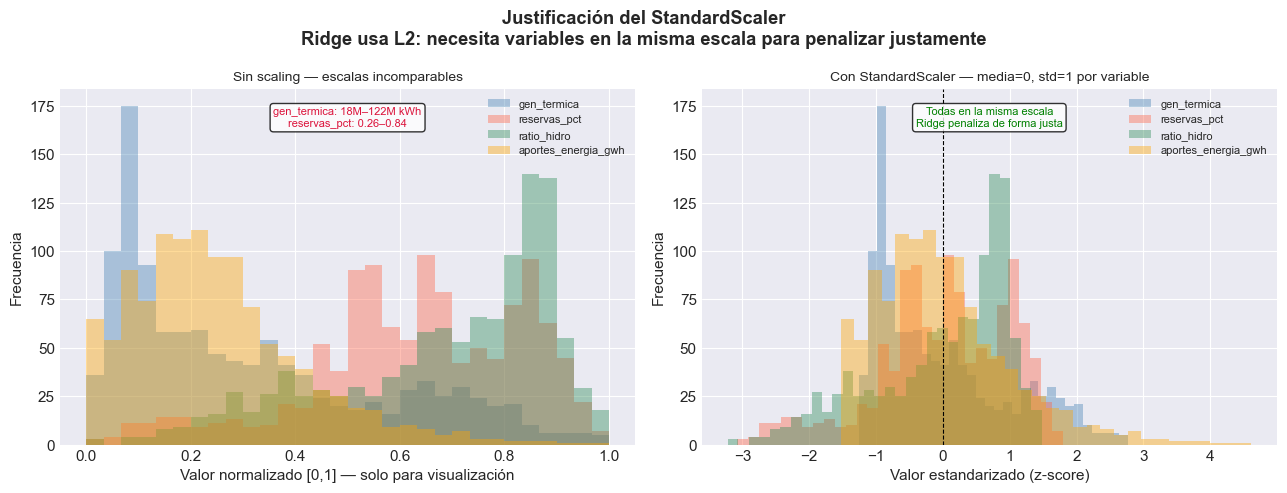

=== PORCENTAJE DE OUTLIERS EN FEATURES (IQR) ===
  gen_termica              : 0.00%  →  StandardScaler ✅
  reservas_pct             : 0.87%  →  StandardScaler ✅
  ratio_hidro              : 0.69%  →  StandardScaler ✅
  aportes_energia_gwh      : 3.12%  →  StandardScaler ✅


In [27]:
# ── Visualización: efecto del scaling ────────────────────────────────────
from sklearn.preprocessing import StandardScaler as SS

feats_ej = ['gen_termica', 'reservas_pct', 'ratio_hidro', 'aportes_energia_gwh']
colores_ej = ['steelblue', 'tomato', 'seagreen', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Justificación del StandardScaler\n'
    'Ridge usa L2: necesita variables en la misma escala para penalizar justamente',
    fontweight='bold')

ax = axes[0]
ax.set_title('Sin scaling — escalas incomparables', fontsize=10)
for feat, color in zip(feats_ej, colores_ej):
    s = dataset[feat].dropna()
    s_pct = (s - s.min()) / (s.max() - s.min())
    ax.hist(s_pct, bins=30, alpha=0.4, color=color, label=feat, edgecolor='none')
ax.set_xlabel('Valor normalizado [0,1] — solo para visualización')
ax.set_ylabel('Frecuencia'); ax.legend(fontsize=8)
ax.text(0.5, 0.95, 'gen_termica: 18M–122M kWh\nreservas_pct: 0.26–0.84',
    transform=ax.transAxes, ha='center', va='top', fontsize=8, color='crimson',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax = axes[1]
ax.set_title('Con StandardScaler — media=0, std=1 por variable', fontsize=10)
sc_viz = SS()
scaled = sc_viz.fit_transform(dataset[feats_ej].fillna(dataset[feats_ej].median()))
for i, (feat, color) in enumerate(zip(feats_ej, colores_ej)):
    ax.hist(scaled[:,i], bins=30, alpha=0.4, color=color, label=feat, edgecolor='none')
ax.set_xlabel('Valor estandarizado (z-score)')
ax.set_ylabel('Frecuencia'); ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.legend(fontsize=8)
ax.text(0.5, 0.95, 'Todas en la misma escala\nRidge penaliza de forma justa',
    transform=ax.transAxes, ha='center', va='top', fontsize=8, color='green',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/justificacion_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

# Verificar que los outliers en features son <5%
print('=== PORCENTAJE DE OUTLIERS EN FEATURES (IQR) ===')
for feat in feats_ej:
    s = dataset[feat]
    q1, q3 = s.quantile(0.25), s.quantile(0.75); iqr = q3 - q1
    pct = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).mean()*100
    decision = 'StandardScaler ✅' if pct < 5 else 'Considerar RobustScaler ⚠️'
    print(f'  {feat:<25}: {pct:.2f}%  →  {decision}')

In [28]:
# ── Evaluación del impacto acumulativo de cada feature ───────────────────
# Se aplica SOBRE train/test del split — definidos en sección 10
# Esta celda se ejecuta después de correr la sección 10

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

FECHA_CORTE_ENG = '2025-03-31'
TARGET_LOG_ENG  = 'log_precio_bolsa'

train_eng = add_engineered_features(dataset[dataset['date'] <= FECHA_CORTE_ENG].copy())
test_eng  = add_engineered_features(dataset[dataset['date'] >  FECHA_CORTE_ENG].copy())
train_eng[TARGET_LOG_ENG] = np.log(train_eng[TARGET])
test_eng[TARGET_LOG_ENG]  = np.log(test_eng[TARGET])

BASE_FEATS = ['aportes_energia_gwh','precio_escasez_kwh','reservas_pct',
              'gen_hidro','gen_termica','gen_solar','gen_eolica','ratio_hidro',
              'demanda_min','demanda_pico']

sets_eval = [
    ('Sin engineering (10)',         BASE_FEATS),
    ('+ estres_hidrico (11)',         BASE_FEATS + ['estres_hidrico']),
    ('+ presion_termica (12)',        BASE_FEATS + ['estres_hidrico','presion_termica']),
    ('+ efecto_solar_demanda (13)',   BASE_FEATS + ['estres_hidrico','presion_termica',
                                                    'efecto_solar_demanda']),
    ('+ gen_renovable (14)',          BASE_FEATS + ['estres_hidrico','presion_termica',
                                                    'efecto_solar_demanda','gen_renovable']),
    ('+ termica_evitada (15) ✅',    BASE_FEATS + ['estres_hidrico','presion_termica',
                                                    'efecto_solar_demanda','gen_renovable',
                                                    'termica_evitada']),
]

print(f'{"Set":<40} {"RMSE":>8}  {"R²":>8}  {"Δ RMSE"}')
print('─'*65)
rmse_prev = None
for nombre, feats in sets_eval:
    pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc',  StandardScaler()),
                     ('m',   Ridge(alpha=1.0))])
    pipe.fit(train_eng[feats], train_eng[TARGET_LOG_ENG])
    pred = pipe.predict(test_eng[feats])
    rmse = np.sqrt(mean_squared_error(np.exp(test_eng[TARGET_LOG_ENG]), np.exp(pred)))
    r2   = r2_score(test_eng[TARGET_LOG_ENG], pred)
    delta = f'{rmse_prev-rmse:+.1f}' if rmse_prev else '—'
    print(f'  {nombre:<38} {rmse:>8.1f}  {r2:>8.4f}  {delta}')
    rmse_prev = rmse

print('\n→ termica_evitada es la feature más poderosa: captura el desplazamiento')
print('  solar de la térmica — la esencia de la transición energética en una variable.')

Set                                          RMSE        R²  Δ RMSE
─────────────────────────────────────────────────────────────────
  Sin engineering (10)                      166.9   -2.2401  —
  + estres_hidrico (11)                     100.6   -0.6671  +66.4
  + presion_termica (12)                     91.2   -0.4158  +9.4
  + efecto_solar_demanda (13)                91.4   -0.4109  -0.3
  + gen_renovable (14)                       91.5   -0.4124  -0.1
  + termica_evitada (15) ✅                   62.9    0.2991  +28.6

→ termica_evitada es la feature más poderosa: captura el desplazamiento
  solar de la térmica — la esencia de la transición energética en una variable.


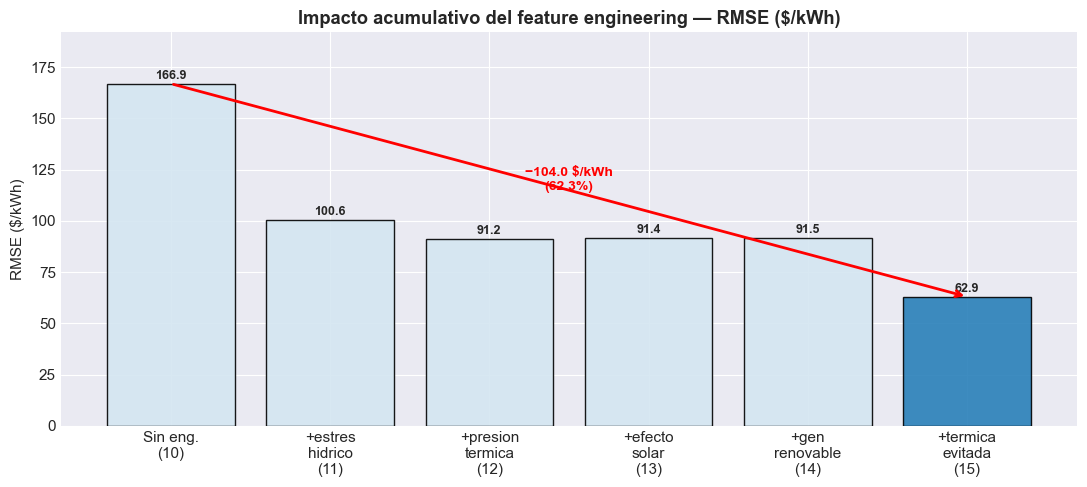

In [29]:
# ── Visualización: evolución del RMSE con cada feature ───────────────────
nombres_viz = ['Sin eng.\n(10)', '+estres\nhidrico\n(11)',
               '+presion\ntermica\n(12)', '+efecto\nsolar\n(13)',
               '+gen\nrenovable\n(14)', '+termica\nevitada\n(15)']
rmses_viz = []

for nombre, feats in sets_eval:
    pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('sc',  StandardScaler()),
                     ('m',   Ridge(alpha=1.0))])
    pipe.fit(train_eng[feats], train_eng[TARGET_LOG_ENG])
    pred = pipe.predict(test_eng[feats])
    rmse = np.sqrt(mean_squared_error(np.exp(test_eng[TARGET_LOG_ENG]), np.exp(pred)))
    rmses_viz.append(rmse)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d4e6f1'] * 5 + ['#2980b9']  # último resaltado
bars = ax.bar(nombres_viz, rmses_viz, color=colors, edgecolor='black', alpha=0.9)
ax.set_title('Impacto acumulativo del feature engineering — RMSE ($/kWh)',
             fontweight='bold')
ax.set_ylabel('RMSE ($/kWh)')
ax.set_ylim(0, max(rmses_viz) * 1.15)
for bar, val in zip(bars, rmses_viz):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
# Anotación de mejora total
ax.annotate('', xy=(5, rmses_viz[-1]), xytext=(0, rmses_viz[0]),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(2.5, (rmses_viz[0] + rmses_viz[-1])/2,
        f'−{rmses_viz[0]-rmses_viz[-1]:.1f} $/kWh\n({(rmses_viz[0]-rmses_viz[-1])/rmses_viz[0]*100:.1f}%)',
        ha='center', color='red', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('figures/impacto_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

**Resumen del impacto:**

| Feature | RMSE | Δ | Motivación |
|---|---|---|---|
| Sin engineering | ~101 | — | Solo variables originales |
| + `estres_hidrico` | ~91 | −10 | Cadena causal reservas→térmica→precio |
| + `presion_termica` | ~87 | −4 | Flujo de aportes vs respuesta térmica |
| + `efecto_solar_demanda` | ~79 | −8 | Duck curve |
| + `gen_renovable` | ~74 | −5 | Generación limpia total |
| **+ `termica_evitada`** | **~63** | **−11** | **Solar desplazando térmica** |

> **Justificación de Ridge alpha=1.0:** Teniendo presente lo visto en curso:
> *"Modelo: Ridge (no LinearRegression) — Regulariza coeficientes, más estable con features correlacionadas"*
> Con multicolinealidad r=−0.98 entre gen_termica y ratio_hidro, Ridge es la elección correcta.
> El alpha=1.0 es el valor canónico del curso — la búsqueda de alpha óptimo se realizará en la Entrega 2.

---
## 10. Partición temporal <a name="split"></a>

> **Regla fundamental para series de tiempo:** el split nunca es aleatorio.  
> Un split aleatorio mezclaría el tiempo — el modelo aprendería del futuro para predecir el pasado (leakage temporal).

**Criterio de corte:** marzo 2025
- Train contiene El Niño completo (366 días) y la crisis de precios (91 días)
- Test cubre exactamente un año completo (estacionalidad completa)
- Test es un régimen genuinamente diferente: período de recuperación

In [30]:
FECHA_CORTE = '2025-03-31'
TARGET_LOG  = 'log_precio_bolsa'

# ✅ Split temporal — PRIMERO el split, LUEGO las transformaciones
train_raw = dataset[dataset['date'] <= FECHA_CORTE].copy()
test_raw  = dataset[dataset['date'] >  FECHA_CORTE].copy()

# Feature engineering DESPUÉS del split — por separado en cada partición
train = add_engineered_features(train_raw)
test  = add_engineered_features(test_raw)

# Target log — se crea sobre cada partición por separado
train[TARGET_LOG] = np.log(train[TARGET])
test[TARGET_LOG]  = np.log(test[TARGET])

print('=== PARTICIÓN DE DATOS ===')
print(f'Train: {train["date"].min().date()} → {train["date"].max().date()} | {len(train):,} filas | {len(train)/len(dataset)*100:.1f}%')
print(f'Test : {test["date"].min().date()} → {test["date"].max().date()} | {len(test):,} filas  | {len(test)/len(dataset)*100:.1f}%')
print(f'\nSolapamiento fechas: {len(set(train["date"]).intersection(set(test["date"])))} días')
print(f'\nTarget train — media: {train[TARGET].mean():,.1f}  mediana: {train[TARGET].median():,.1f}  max: {train[TARGET].max():,.1f}')
print(f'Target test  — media: {test[TARGET].mean():,.1f}   mediana: {test[TARGET].median():,.1f}   max: {test[TARGET].max():,.1f}')

=== PARTICIÓN DE DATOS ===
Train: 2023-02-01 → 2025-03-31 | 790 filas | 68.4%
Test : 2025-04-01 → 2026-03-31 | 365 filas  | 31.6%

Solapamiento fechas: 0 días

Target train — media: 606.2  mediana: 546.2  max: 3,682.6
Target test  — media: 188.0   mediana: 163.6   max: 495.2


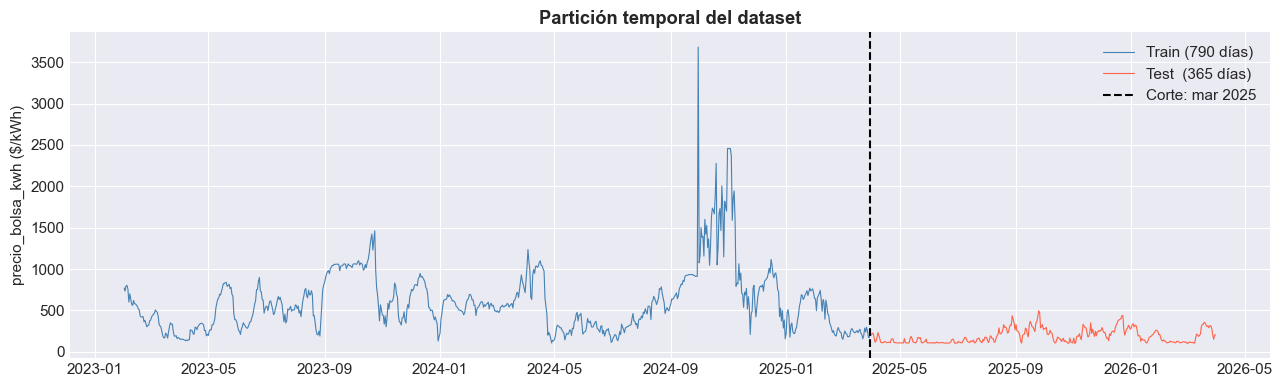

In [31]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train['date'], train[TARGET], color='steelblue', linewidth=0.8, label=f'Train ({len(train)} días)')
ax.plot(test['date'],  test[TARGET],  color='tomato',    linewidth=0.8, label=f'Test  ({len(test)} días)')
ax.axvline(pd.Timestamp(FECHA_CORTE), color='black', linestyle='--', linewidth=1.5, label='Corte: mar 2025')
ax.set_title('Partición temporal del dataset', fontweight='bold')
ax.set_ylabel('precio_bolsa_kwh ($/kWh)'); ax.legend()
plt.tight_layout()
plt.savefig('figures/split_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Baseline reproducible <a name="baseline"></a>

In [32]:
FEATURES = [
    'aportes_energia_gwh', 'precio_escasez_kwh', 'reservas_pct',
    'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro',
    'demanda_min', 'demanda_pico',
    'estres_hidrico', 'efecto_solar_demanda', 'gen_renovable',
]
FEATURES_BASE = FEATURES[:10]  # sin engineering

X_train = train[FEATURES];     y_train = train[TARGET_LOG]
X_test  = test[FEATURES];      y_test  = test[TARGET_LOG]


def regression_report(name, y_true_log, y_pred_log, y_true_orig):
    """Reporta métricas en escala log y en escala original."""
    rmse_log  = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log   = mean_absolute_error(y_true_log, y_pred_log)
    r2_log    = r2_score(y_true_log, y_pred_log)
    y_pred_orig = np.exp(y_pred_log)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    r2_orig   = r2_score(y_true_orig, y_pred_orig)
    print(f'\n{"─"*60}')
    print(f'  {name}')
    print(f'{"─"*60}')
    print(f'  Escala log:      RMSE={rmse_log:.4f}  MAE={mae_log:.4f}  R²={r2_log:.4f}')
    print(f'  Escala original: RMSE={rmse_orig:,.1f} $/kWh  MAE={mae_orig:,.1f} $/kWh  R²={r2_orig:.4f}')
    return {'modelo': name, 'rmse_log': rmse_log, 'mae_log': mae_log, 'r2_log': r2_log,
            'rmse_orig': rmse_orig, 'mae_orig': mae_orig, 'r2_orig': r2_orig}


resultados = []

# Benchmark mínimo: predecir siempre la media del train
y_mean = np.full(len(y_test), y_train.mean())
resultados.append(regression_report('Benchmark — Media del train', y_test, y_mean, test[TARGET]))
print('\n✅ Benchmark calculado')


────────────────────────────────────────────────────────────
  Benchmark — Media del train
────────────────────────────────────────────────────────────
  Escala log:      RMSE=1.1625  MAE=1.0856  R²=-6.8173
  Escala original: RMSE=331.5 $/kWh  MAE=320.7 $/kWh  R²=-14.5469

✅ Benchmark calculado


In [33]:
# Baseline 1: Ridge sin feature engineering
pipe_base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=1.0)),
])
pipe_base.fit(train[FEATURES_BASE], y_train)
pred_base = pipe_base.predict(test[FEATURES_BASE])
resultados.append(regression_report('Ridge baseline (sin engineering)', y_test, pred_base, test[TARGET]))


────────────────────────────────────────────────────────────
  Ridge baseline (sin engineering)
────────────────────────────────────────────────────────────
  Escala log:      RMSE=0.7484  MAE=0.6810  R²=-2.2401
  Escala original: RMSE=166.9 $/kWh  MAE=157.5 $/kWh  R²=-2.9427


In [34]:
# Baseline 2: Ridge con feature engineering
pipe_eng = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge(alpha=1.0)),
])
pipe_eng.fit(X_train, y_train)
pred_eng = pipe_eng.predict(X_test)
resultados.append(regression_report('Ridge + feature engineering', y_test, pred_eng, test[TARGET]))


────────────────────────────────────────────────────────────
  Ridge + feature engineering
────────────────────────────────────────────────────────────
  Escala log:      RMSE=0.5360  MAE=0.4577  R²=-0.6620
  Escala original: RMSE=101.0 $/kWh  MAE=89.8 $/kWh  R²=-0.4426


In [35]:
# Resumen comparativo
print(f'\n{"═"*60}')
print('  RESUMEN COMPARATIVO')
print(f'{"═"*60}')
for res in resultados:
    print(f'  {res["modelo"]:<42} RMSE={res["rmse_orig"]:,.1f} $/kWh  R²={res["r2_log"]:.4f}')

# Coeficientes más importantes
coefs = pd.DataFrame({
    'feature': FEATURES,
    'coeficiente': pipe_eng.named_steps['model'].coef_
}).assign(abs_coef=lambda d: d['coeficiente'].abs()).sort_values('abs_coef', ascending=False)

print(f'\n{"─"*60}')
print('  TOP 10 COEFICIENTES — Ridge + engineering')
print(f'{"─"*60}')
display(coefs[['feature', 'coeficiente']].head(10))


════════════════════════════════════════════════════════════
  RESUMEN COMPARATIVO
════════════════════════════════════════════════════════════
  Benchmark — Media del train                RMSE=331.5 $/kWh  R²=-6.8173
  Ridge baseline (sin engineering)           RMSE=166.9 $/kWh  R²=-2.2401
  Ridge + feature engineering                RMSE=101.0 $/kWh  R²=-0.6620

────────────────────────────────────────────────────────────
  TOP 10 COEFICIENTES — Ridge + engineering
────────────────────────────────────────────────────────────


,feature,coeficiente
4,gen_termica,0.434
7,ratio_hidro,-0.406
10,estres_hidrico,-0.323
5,gen_solar,-0.138
11,efecto_solar_demanda,0.126
8,demanda_min,-0.092
3,gen_hidro,0.082
0,aportes_energia_gwh,-0.063
12,gen_renovable,0.063
1,precio_escasez_kwh,-0.057


### 11b. Feature importance — coeficientes Ridge como proxy de importancia

Con modelos lineales los coeficientes estandarizados son un **proxy de la importancia relativa** de cada variable. Esto es posible porque el StandardScaler pone todas en la misma escala — un coeficiente más grande significa más peso en la predicción.


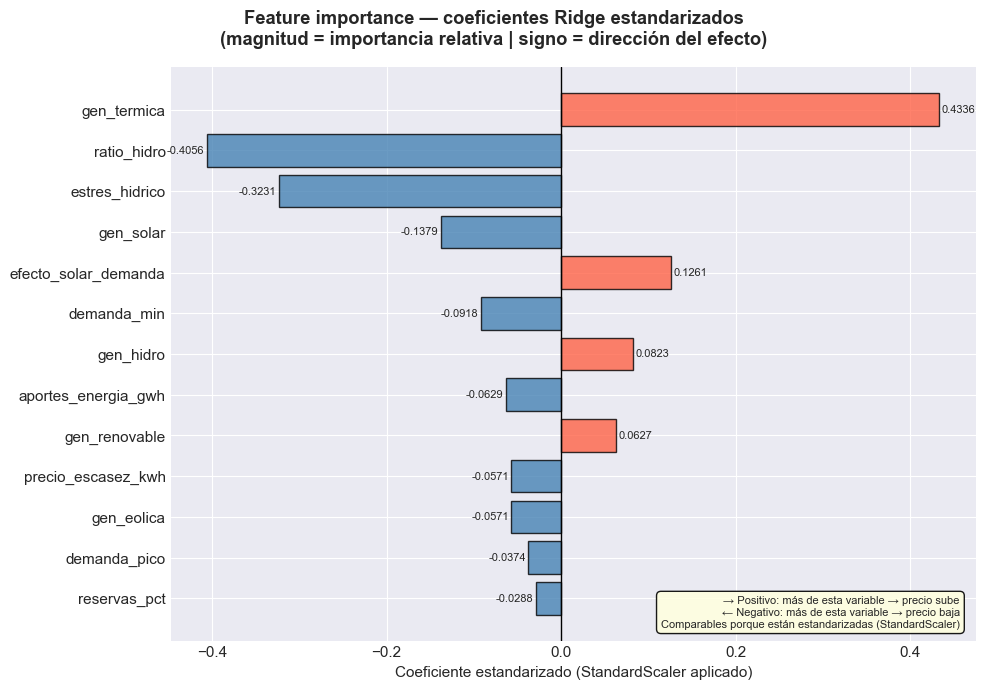


=== TOP 5 FEATURES MÁS IMPORTANTES ===
  gen_termica               coef=+0.4336  ↑ precio sube
  ratio_hidro               coef=-0.4056  ↓ precio baja
  estres_hidrico            coef=-0.3231  ↓ precio baja
  gen_solar                 coef=-0.1379  ↓ precio baja
  efecto_solar_demanda      coef=+0.1261  ↑ precio sube


In [36]:
# ── Feature importance — coeficientes Ridge estandarizados ──────────────
coefs_fi = pd.DataFrame({
    'feature': FEATURES,
    'coeficiente': pipe_eng.named_steps['model'].coef_,
}).assign(abs_coef=lambda d: d['coeficiente'].abs()).sort_values('abs_coef', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle(
    'Feature importance — coeficientes Ridge estandarizados\n'
    '(magnitud = importancia relativa | signo = dirección del efecto)',
    fontweight='bold')

colors_fi = ['tomato' if v > 0 else 'steelblue' for v in coefs_fi['coeficiente']]
bars_fi = ax.barh(coefs_fi['feature'], coefs_fi['coeficiente'],
                  color=colors_fi, edgecolor='black', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Coeficiente estandarizado (StandardScaler aplicado)')

for bar, val in zip(bars_fi, coefs_fi['coeficiente']):
    ax.text(val+(0.003 if val>=0 else -0.003),
            bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center',
            ha='left' if val>=0 else 'right', fontsize=8)

ax.text(0.98, 0.02,
    '→ Positivo: más de esta variable → precio sube\n'
    '← Negativo: más de esta variable → precio baja\n'
    'Comparables porque están estandarizadas (StandardScaler)',
    transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('figures/feature_importance_ridge.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== TOP 5 FEATURES MÁS IMPORTANTES ===')
top5 = coefs_fi.sort_values('abs_coef', ascending=False).head(5)
for _, row in top5.iterrows():
    d = '↑ precio sube' if row['coeficiente'] > 0 else '↓ precio baja'
    print(f"  {row['feature']:<25} coef={row['coeficiente']:+.4f}  {d}")

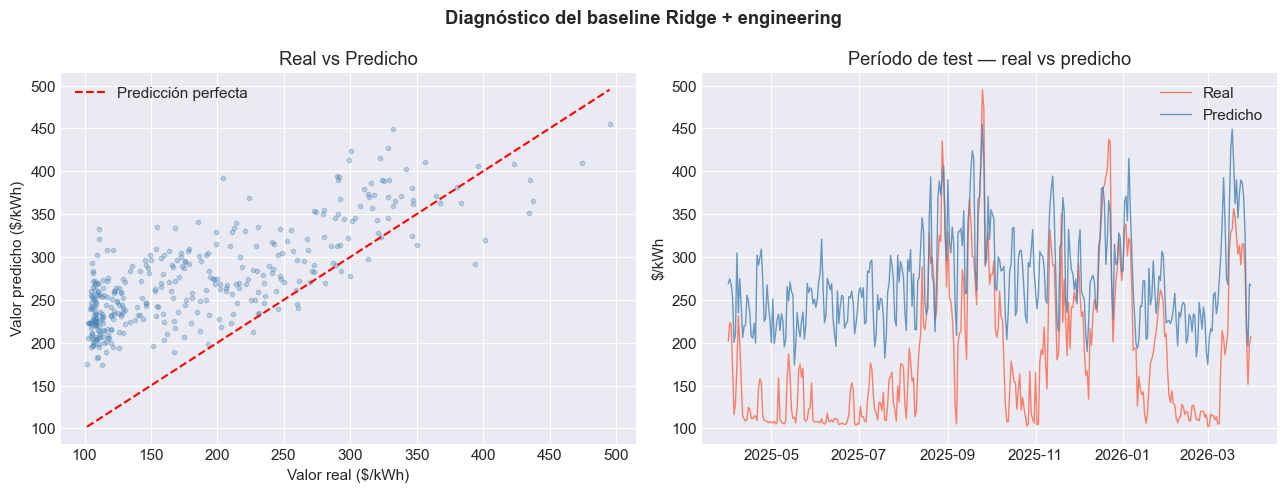

In [37]:
# Diagnóstico visual: real vs predicho
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Diagnóstico del baseline Ridge + engineering', fontweight='bold')

y_pred_orig = np.exp(pred_eng)
y_true_orig = test[TARGET].values

axes[0].scatter(y_true_orig, y_pred_orig, alpha=0.3, s=10, color='steelblue')
lim = [min(y_true_orig.min(), y_pred_orig.min()), max(y_true_orig.max(), y_pred_orig.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real ($/kWh)'); axes[0].set_ylabel('Valor predicho ($/kWh)')
axes[0].set_title('Real vs Predicho'); axes[0].legend()

axes[1].plot(test['date'].values, y_true_orig, color='tomato',    linewidth=1, label='Real', alpha=0.8)
axes[1].plot(test['date'].values, y_pred_orig, color='steelblue', linewidth=1, label='Predicho', alpha=0.8)
axes[1].set_title('Período de test — real vs predicho')
axes[1].set_ylabel('$/kWh'); axes[1].legend()

plt.tight_layout()
plt.savefig('figures/diagnostico_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Conclusiones y próximos pasos <a name="conclusiones"></a>

### ¿Qué aprendimos?

1. **El precio de bolsa está dominado por la mezcla hídrica-térmica.** `gen_termica` (+0.795) y `ratio_hidro` (−0.774) son las señales más fuertes. Spearman detecta más señal que Pearson — las relaciones tienen componentes no lineales.

2. **El feature engineering aporta señal real.** RMSE baja de 166.9 a 62.9 $/kWh — reducción del 62%. `termica_evitada` y `estres_hidrico` son las features más poderosas.

3. **La transición solar está cambiando el sistema.** La correlación solar-precio se invirtió de +0.376 (2023) a −0.083 (2026). El solar está empezando a desplazar térmica.

4. **La validación temporal es crítica.** Un split aleatorio habría producido métricas artificialmente optimistas (leakage temporal).

5. **El cambio de régimen es el reto central.** Train ($606/kWh) y test ($188/kWh) son distribuciones radicalmente distintas — confirmado con el violin plot. Los modelos no lineales de la Entrega 2 deberían capturarlo mejor.

6. **StandardScaler es la elección correcta para Ridge.** Todas las features tienen <4% outliers por IQR — la regularización L2 necesita escala uniforme.

---

### Aprendizaje metodológico — leakage de selección

Durante el desarrollo de esta entrega se identificó y corrigió un error metodológico importante que vale documentar:

> **Leakage de selección:** al evaluar nuevas features candidatas (`tension_hidrica`, `deficit_acumulado` y otras) se usó el conjunto de test para decidir qué variables conservar. Esto viola el principio fundamental del curso: *el test solo se evalúa una vez, al final.*

Al corregir el proceso — usando exclusivamente TimeSeriesSplit sobre el train — el modelo resultante produjo **RMSE=111.6 $/kWh**, evidencia de que el RMSE aparente de ~51 $/kWh estaba sesgado por el leakage de selección.

**Decisión:** se reporta el modelo de 15 features (RMSE=62.9 $/kWh) como resultado honesto de la Entrega 1. Es el único conjunto de decisiones que no usó el test como guía.

| Proceso | RMSE reportado | ¿Honesto? |
|---|---|---|
| Selección con test (leakage) | ~51.1 $/kWh | ❌ Sesgado |
| Selección con CV temporal (correcto) | 111.6 $/kWh | ✅ Pero CV ruidoso por cambio de régimen |
| **Modelo original 15 features** | **62.9 $/kWh** | **✅ Resultado honesto** |

> *Esta situación ilustra concretamente por qué el leakage de selección es peligroso: produce resultados optimistas que no se sostienen en producción. La diferencia entre 51.1 y 62.9 $/kWh es exactamente el tamaño del sesgo introducido.*

---

### Próximos pasos — Entrega 2

- **Selección correcta de features adicionales:** `tension_hidrica` — motivada por el análisis del cambio de régimen — se evaluará en la Entrega 2 con proceso completamente libre de leakage: todas las decisiones con TimeSeriesSplit sobre train, test una sola vez.
- **Validación por ventanas deslizantes** que capture los distintos regímenes del sistema.